# Measuring the quantum Fisher information with classical shadows

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 10 — Quantum metrology protocols*

## 1. Introduction and motivation

Everything Chapter 10 has computed so far started from a state vector stored in a computer. An experiment does not
have one. It has a machine that prepares a state, and a detector that produces bit strings. The question of this
notebook is therefore the practical one:

> Given a laboratory that can rotate each qubit and measure it, how many measurements does it take to **know** the
> quantum Fisher information of the state it just prepared, and with what error bar?

The answer matters for experiments. $F_Q>N$ certifies entanglement, $F_Q>kN$ certifies that at least $k+1$
particles are genuinely entangled, and the same number carries an operational promise: a phase uncertainty
$\Delta\theta\ge1/\sqrt{\nu F_Q}$ after $\nu$ repetitions of the interferometer. A claim of "entanglement depth
$12$" based on the quantum Fisher information is a claim about a *measured* $F_Q$ with a *measured* uncertainty,
and it is only as good as the statistics behind it.

The obstacle is that $F_Q$ is a *nonlinear* function of the state. Quantum mechanics gives unbiased estimators of
*linear* functionals $\mathrm{Tr}(\rho O)$ directly, and nothing else. There are two ways out, and both appear
below.

* For a **pure state** and a collective generator $G=\mathbf n\cdot\mathbf J$ the nonlinearity is mild:
  $F_Q=4\,\mathrm{Var}(G)=4\left(\langle G^2\rangle-\langle G\rangle^2\right)$ involves only one- and two-body
  Pauli expectation values — $O(N^2)$ numbers, each of weight at most $2$ — plus one squared mean. Classical
  shadows (notebook 24) estimate all of them from a *single* data set, with a variance that does not grow with
  $N$. The squared mean is the only nonlinear part, it biases the naive estimator by a computable amount, and a
  $U$-statistic removes the bias exactly.
* For a **mixed state** $4\,\mathrm{Var}(G)$ is only an upper bound on $F_Q$, and it can be wildly wrong: we will
  exhibit a state whose $4\,\mathrm{Var}(J_z)$ is $N^2$ while its true $F_Q$ is $0.15$. What randomised
  measurements can still deliver is a *converging series of lower bounds* $F_0\le F_1\le\cdots\le F_Q$, each a
  polynomial in $\rho$, which we derive from a geometric series and verify against the exact
  symmetric-logarithmic-derivative value.

**Road map.**

* **Section 3** is a one-page recap of classical shadows: the protocol, the single-snapshot estimator of a Pauli
  string, and the $3^k$ variance law.
* **Section 4** derives the $3\times3$ quantum Fisher information matrix in terms of $\langle\sigma^a_i\rangle$
  and $\langle\sigma^a_i\sigma^b_j\rangle$, and counts the observables.
* **Section 5** implements the estimator twice: once literally, as a sum over $O(N^2)$ Pauli strings, and once in
  a form that needs only **six numbers per snapshot** regardless of $N$. The two agree to machine precision.
* **Section 6** derives the bias of the plug-in estimator, $-\left(\mathcal{F}_{aa}+2N\right)/M$ exactly, and
  removes it.
* **Section 7** puts bootstrap error bars on the whole matrix, derives the per-snapshot standard deviation of the
  cat-state estimate, and measures the statistical error of $F_{\max}$ and of the optimal generator direction
  against $M$ and against $N$.
* **Section 8** applies the machinery to a coherent state, to three one-axis-twisting states, to GHZ, and to a
  Haar-scrambled cat of notebook 35.
* **Section 9** turns the variance into a **snapshot budget**: how many measurements are needed to certify
  $F_Q>N$ and $F_Q>kN$ at a given confidence, predicted and then verified by simulation.
* **Section 10** is the mixed-state story: the upper bound and its failure, the polynomial lower bounds, their
  derivation, their verification against the exact value, and their estimation from shadows.
* **Section 11** measures the cost of the two implementations of the estimator.

### What you will learn

*Physics*

* that the collective quantum Fisher information of a pure state is a *two-body* quantity, hence measurable with
  $O(N^2)$ observables rather than the $4^N$ of full tomography;
* how an entanglement-depth claim is actually certified from data, and what a snapshot budget looks like;
* why $4\,\mathrm{Var}(G)$ is the wrong thing to measure on a noisy state, and what the right thing is;
* the monotone hierarchy of polynomial lower bounds on the quantum Fisher information, and when it is already
  tight at the first member.

*Numerical methods*

* bias of a plug-in estimator of a nonlinear functional, computed exactly, and the $U$-statistic that removes it;
* bootstrap error bars for quantities built from *correlated* estimates that share the same snapshots;
* error propagation from an estimated matrix to its largest eigenvalue and eigenvector;
* a geometric-series construction of converging polynomial lower bounds, and the sample-splitting estimator of a
  quantity quadratic in $\rho$.

*Implementation practice*

* chunked `vmap` collection of large randomised-measurement data sets with `jax.random.fold_in`;
* rewriting an $O(MN^2)$ estimator as an $O(MN)$ one by recognising a sum of products as a product of sums;
* reusing one data set for every quantity in a section instead of re-simulating the experiment.

### Prerequisites
* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, PRNG keys;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): Born rule, basis rotations, shot noise;
* [24 — classical shadows](../ch08_quantum_information_protocols/24_classical_shadows.ipynb): the randomised
  measurement channel, the single-snapshot estimator, the $3^k$ variance law, median of means. Section 3 recalls
  everything used here;
* [29 — quantum Fisher information](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb):
  $F_Q=4\,\mathrm{Var}(G)$, the $3\times3$ matrix, the entanglement-witness inequalities;
* [30 — QFI from the SLD](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb):
  the mixed-state formula used in Section 11;
* helpful: [33 — spin squeezing](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb),
  [34 — one-axis twisting to GHZ](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb)
  and [35 — scrambling a metrological probe](../ch10_quantum_metrology_protocols/35_oat_plus_haar_scrambling.ipynb),
  which supply the states of Section 9.

**Conventions.** Qubit $q$ = tensor axis $q$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$. Collective spins are
$J_a=\tfrac12\sum_q\sigma^a_q$, so the standard quantum limit is $F_Q=N$ and the Heisenberg limit $F_Q=N^2$.
$M$ always denotes the number of randomised-measurement snapshots.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we reuse the state constructors, `apply_gate` / `apply_gate_dm` / `apply_kraus_dm`,
`collect_pauli_shadows` and `shadow_estimate_pauli` (the randomised-measurement primitives),
`apply_collective` and `spin_moments` (the exact quantum Fisher information matrix we validate against),
`qfi_mixed` and `collective_dense` (the exact mixed-state value of Section 11), `oat_evolve` and `haar_unitary`
(the states of Section 9). Everything specific to this notebook is built below.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; m = Kraus index, summed!)
        "mAa, mBc, abcd -> AbBd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U

# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_pure(psi, P=Z, qubits=None):
    """Quantum Fisher information of a pure state for the phase imprinted by exp(-i theta J),
    J = (1/2) sum_q P_q:
        F_Q = 4 Var(J) = <G^2> - <G>^2   with G = sum_q P_q = 2J.
    Cramer-Rao: Delta theta >= 1/sqrt(M F_Q).  Product states F_Q <= N (standard quantum limit);
    GHZ: F_Q = N^2 (Heisenberg limit).   Matrix-free: |phi> = G|psi>,  <G^2> = <phi|phi>,  <G> = <psi|phi>."""
    phi = apply_collective(psi, P, qubits)
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2

def qfi_mixed(rho_mat, G_mat, tol=1e-12):
    """QFI of a MIXED state (symmetric-logarithmic-derivative formula), rho = sum_m l_m |m><m|:
        F_Q = 2 sum_{m,n : l_m+l_n>0} (l_m - l_n)^2/(l_m + l_n) |<m|G|n>|^2       (G = generator, e.g. J).
    Reduces to 4 Var(G) for pure states.  Dense eigendecomposition -> use on small / reduced states."""
    lam, v = jnp.linalg.eigh(rho_mat)
    G = v.conj().T @ G_mat @ v
    num = (lam[:, None] - lam[None, :]) ** 2
    den = lam[:, None] + lam[None, :]
    return 2 * jnp.sum(jnp.where(den > tol, num / jnp.where(den > tol, den, 1.0), 0.0) * jnp.abs(G) ** 2)

def collective_dense(P, n):
    """Dense J = (1/2) sum_q P_q on n qubits (input of `qfi_mixed`), built from the matrix-free action
    on the basis vectors (vmap), exactly like `dense_hamiltonian`."""
    eye = jnp.eye(2 ** n, dtype=CDTYPE).reshape((2 ** n,) + (2,) * n)
    return 0.5 * jax.vmap(lambda e: apply_collective(e, P).reshape(-1))(eye).T

def spin_moments(psi):
    """Mean collective spin <J_a> (shape 3) and symmetrised covariance matrix
        C_ab = (1/2)<J_a J_b + J_b J_a> - <J_a><J_b>          (shape 3x3).
    Trick: |phi_a> = J_a|psi>  =>  <J_a J_b> = <phi_a|phi_b>, and its real part is the symmetrised moment."""
    phis = [0.5 * apply_collective(psi, P) for P in (X, Y, Z)]
    mean = jnp.stack([jnp.real(jnp.vdot(psi, p)) for p in phis])
    second = jnp.stack([jnp.stack([jnp.real(jnp.vdot(a, b)) for b in phis]) for a in phis])
    return mean, second - jnp.outer(mean, mean)

def oat_evolve(psi, chi_t):
    """One-axis twisting  exp(-i chi t J_z^2)  applied EXACTLY.
    J_z is diagonal in the computational basis with eigenvalue m(s) = sum_q (1/2 - s_q), so the evolution
    multiplies each amplitude by a phase exp(-i chi t m^2): O(2^N), no Trotter error, no gates.
    m(s) is assembled by BROADCASTING N arrays of shape (1,..,2,..,1) -- a tensor-network-free way of
    writing a sum over sites.   [Note: chi sum_{i<j} Z_i Z_j = 2 chi J_z^2 - chi N/2.]"""
    N = psi.ndim
    m = sum(jnp.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))
    return psi * jnp.exp(-1j * chi_t * m ** 2)


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]


# ----------------------------------------------------------------------------
# 13. Classical shadows (random Pauli measurements)
# ----------------------------------------------------------------------------
def collect_pauli_shadows(key, psi, n_shadows):
    """Randomised-measurement data set (Huang, Kueng, Preskill 2020).
    Each snapshot: draw a basis b_q in {X,Y,Z} for every qubit, rotate, measure all qubits once.
    Returns (bases, bits), int arrays of shape (n_shadows, N); basis code 0=X, 1=Y, 2=Z.
    JAX: one snapshot is a pure function of its key  ->  `vmap` over keys gives all snapshots in parallel;
         `rots[bases[q]]` selects the rotation with a traced index (gather), so no Python branching."""
    N = psi.ndim
    rots = jnp.stack([_BASIS_ROT["X"], _BASIS_ROT["Y"], _BASIS_ROT["Z"]])

    def one(k):
        kb, ks = jax.random.split(k)
        bases = jax.random.randint(kb, (N,), 0, 3)
        phi = psi
        for q in range(N):
            phi = apply_gate(phi, rots[bases[q]], [q])
        logp = jnp.log(jnp.clip(jnp.abs(phi.reshape(-1)) ** 2, 1e-300, None))
        idx = jax.random.categorical(ks, logp)
        bits = (idx >> jnp.arange(N - 1, -1, -1)) & 1
        return bases, bits

    return jax.vmap(one)(jax.random.split(key, n_shadows))

def shadow_estimate_pauli(bases, bits, ops):
    """Estimate <P> of a Pauli string `ops` = {qubit: 'X'|'Y'|'Z'} from Pauli shadows.
        single-snapshot estimator   o = prod_{q in supp(P)}  3 * [b_q == P_q] * (-1)^{bit_q}
    (the factor 3 per qubit inverts the measurement channel; a snapshot contributes only if all its bases
    match on the support -- probability 3^{-k} -- hence variance ~ 3^k for weight-k strings).
    Returns (mean, standard error)."""
    code = {"X": 0, "Y": 1, "Z": 2}
    val = jnp.ones(bases.shape[0])
    for q, p in ops.items():
        val = val * 3.0 * (bases[:, q] == code[p]) * (1 - 2 * bits[:, q])
    return jnp.mean(val), jnp.std(val) / jnp.sqrt(val.shape[0])


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})
PAULI_LETTERS = "IXYZ"


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def pauli_direction(n):
    """Single-qubit matrix n.sigma = n_x X + n_y Y + n_z Z for a real 3-vector n."""
    n = jnp.asarray(n, dtype=CDTYPE)
    return n[0] * X + n[1] * Y + n[2] * Z


def qfi_matrix_exact(psi):
    """EXACT 3x3 quantum Fisher information matrix of a pure state (the reference of notebook 29).

    MATH   Fcal[a,b] = 4 ( (1/2)<J_a J_b + J_b J_a> - <J_a><J_b> ),   F_Q(n) = n^T Fcal n.
    """
    _, cov = spin_moments(psi)
    return 4.0 * cov


def optimal_direction(F):
    """(F_max, n_opt) of a 3x3 QFI matrix: largest eigenvalue and its eigenvector."""
    w, v = jnp.linalg.eigh(jnp.asarray(F))
    return w[-1], v[:, -1]


def clean_direction(n):
    """Fix the irrelevant global sign of an eigenvector and round numerical zeros away, for printing."""
    n = np.array(n, dtype=float)
    n = n * np.sign(n[int(np.argmax(np.abs(n)))])
    return np.where(np.abs(n) < 1e-9, 0.0, n)


def timed(f, *args, budget=0.3, min_reps=3, max_reps=200):
    """Return (result, compile_time, best_run_time); JAX is asynchronous, so every value is blocked on."""
    t0 = time.time()
    out = jax.block_until_ready(f(*args))
    t_compile = time.time() - t0
    best, n, t_start = np.inf, 0, time.time()
    while n < min_reps or (time.time() - t_start < budget and n < max_reps):
        t0 = time.time()
        out = jax.block_until_ready(f(*args))
        best = min(best, time.time() - t0)
        n += 1
    return out, t_compile, best

## 3. Classical shadows, recalled

The protocol of notebook 24, in four lines. For each of $M$ repetitions:

1. draw a measurement basis $c_q\in\{X,Y,Z\}$ independently and uniformly for every qubit;
2. rotate qubit $q$ into that basis ($U=H$ for $X$, $U=HS^\dagger$ for $Y$, $U=\mathbb 1$ for $Z$);
3. measure all qubits in the computational basis, obtaining bits $b_q\in\{0,1\}$;
4. store the pair of integer rows $(c,b)$ — that is the whole record. No amplitudes, no matrices.

For a Pauli string $P=\bigotimes_qP_q$ with support $\mathrm{supp}(P)$ of size $k$ (the **weight**), the
single-snapshot estimator derived in notebook 24 is

$$\hat o(P)=\prod_{q\in\mathrm{supp}(P)}3\,(-1)^{b_q}\left[\,c_q=P_q\,\right], \tag{1}$$

with $[\cdot]$ the indicator function. A snapshot contributes only if it happened to measure the right axis on
every qubit of the support — probability $3^{-k}$ — and the factor $3^k$ compensates for that exactly, so
$\mathbb E[\hat o]=\langle P\rangle$. Squaring Eq. (1) and using $\left((-1)^b\right)^2=1$ gives the variance law

$$\mathbb E\left[\hat o^{\,2}\right]=3^k,\qquad\mathrm{Var}(\hat o)=3^k-\langle P\rangle^2, \tag{2}$$

**independent of $N$**. Everything in this notebook has weight $1$ or $2$, so the relevant numbers are $3$ and
$9$ and nothing ever grows with the system size.

The estimate of $\langle P\rangle$ from the whole data set is the sample mean $\tfrac1M\sum_m\hat o_m(P)$, and its
standard error is the sample standard deviation divided by $\sqrt M$. The collection itself is the engine's
`collect_pauli_shadows` wrapped in a chunked loop so that the batched intermediate — `chunk` copies of the
rotated state — stays inside memory.

In [4]:
# ==============================================================================
# STEP 1: chunked collection of a randomised-measurement data set
# ==============================================================================
_collect_jit = jax.jit(collect_pauli_shadows, static_argnums=(2,))      # cache: one compile per (N, chunk)


def collect_shadows(key, psi, n_shadows, chunk=8192):
    """M randomised-measurement snapshots of a PURE state, collected in blocks.

    MATH   one snapshot = (a random basis per qubit, one bit string sampled from the Born rule)
    IMPL   `collect_pauli_shadows` vmaps over keys; we call it on blocks of `chunk` so the batched
           intermediate (chunk x 2^N complex numbers) stays small.  Block j uses fold_in(key, j).
    COST   O(M N 2^N) time, O(chunk 2^N) memory.   Returns (bases, bits): int arrays of shape (M, N),
           basis code 0 = X, 1 = Y, 2 = Z.
    """
    bs, ts, done = [], [], 0
    while done < n_shadows:
        c = min(chunk, n_shadows - done)
        b, t = _collect_jit(jax.random.fold_in(key, done), psi, c)
        bs.append(b)
        ts.append(t)
        done += c
    return jnp.concatenate(bs), jnp.concatenate(ts)


def pauli_digits(labels):
    """Pauli-string labels -> int array (K, N) with digits 0=I, 1=X, 2=Y, 3=Z."""
    return jnp.asarray([[PAULI_LETTERS.index(ch) for ch in lab] for lab in labels], dtype=jnp.int32)


@jax.jit
def snapshot_values(bases, bits, digits):
    """Eq. (1) for every snapshot and every Pauli string.  Returns a real (M, K) array.

    IMPL   for each qubit build the 4-entry lookup (1, 3s[c=X], 3s[c=Y], 3s[c=Z]) with s = (-1)^bit,
           then gather the digit of every string:  tab[:, digits[:, q]] is (M, K).  Multiply the N of them.
    COST   O(M K N), integers only, no branching.
    """
    Mn, N = bases.shape
    sgn = (1 - 2 * bits).astype(RDTYPE)
    out = jnp.ones((Mn, digits.shape[0]), dtype=RDTYPE)
    for q in range(N):
        tab = jnp.stack([jnp.ones(Mn, dtype=RDTYPE)]
                        + [3.0 * (bases[:, q] == p) * sgn[:, q] for p in range(3)], axis=1)
        out = out * tab[:, digits[:, q]]
    return out


# --- CHECKPOINT: Eq. (1) against the engine and against the exact values ----------------
N_DEMO, M_DEMO = 5, 20_000
psi_demo = oat_evolve(product_state("+" * N_DEMO), np.pi / 2)          # the one-axis-twisting cat of notebook 34
t0 = time.time()
bases_demo, bits_demo = collect_shadows(jax.random.PRNGKey(0), psi_demo, M_DEMO)
print(f"collected {M_DEMO} snapshots of a {N_DEMO}-qubit state in {time.time() - t0:.1f} s "
      f"(including compilation)")
print(f"the data set is two integer arrays of shape {tuple(bases_demo.shape)}: "
      f"{bases_demo.size * 2} integers in total\n")

demo_labels = ["ZIIII", "IYIII", "ZZIII", "XIIIX", "YYIII", "XZIII"]
vals_demo = snapshot_values(bases_demo, bits_demo, pauli_digits(demo_labels))
print(f"{'P':>7s} {'weight':>7s} {'exact <P>':>10s} {'shadow estimate':>22s} {'engine':>9s} {'E[o^2]':>9s} "
      f"{'3^k':>6s}")
worst = 0.0
for i, lab in enumerate(demo_labels):
    ops = {q: ch for q, ch in enumerate(lab) if ch != "I"}
    exact = float(expect_pauli_string(psi_demo, ops))
    eng, _ = shadow_estimate_pauli(bases_demo, bits_demo, ops)
    mean_i = float(vals_demo[:, i].mean())
    sem_i = float(vals_demo[:, i].std()) / np.sqrt(M_DEMO)
    worst = max(worst, abs(mean_i - exact) / sem_i)
    print(f"{lab:>7s} {len(ops):7d} {exact:10.3f} {mean_i:10.3f} +- {sem_i:<8.3f} {float(eng):9.3f} "
          f"{float((vals_demo[:, i] ** 2).mean()):9.2f} {3.0 ** len(ops):6.0f}")
    assert abs(float(eng) - mean_i) < 1e3 * TOL
print(f"\nCHECKPOINT our vectorised Eq. (1) reproduces the engine exactly; the largest deviation from the exact "
      f"value is {worst:.2f} standard errors, and the measured second moments sit on 3^k.")
assert worst < 4.0

# --- WRONG CONTROL: drop the inverse-channel factor 3 per qubit (estimate = o / 3^k) -------
worst_wrong = 0.0
for i, lab in enumerate(demo_labels):
    k = sum(ch != "I" for ch in lab)
    ops = {q: ch for q, ch in enumerate(lab) if ch != "I"}
    col = vals_demo[:, i] / 3.0 ** k
    worst_wrong = max(worst_wrong, abs(float(col.mean()) - float(expect_pauli_string(psi_demo, ops)))
                      / (float(col.std()) / np.sqrt(M_DEMO)))
print(f"WRONG CONTROL without the factor 3 per qubit the largest deviation is {worst_wrong:.1f} standard errors")
assert worst_wrong > 4.0

collected 20000 snapshots of a 5-qubit state in 4.4 s (including compilation)
the data set is two integer arrays of shape (20000, 5): 200000 integers in total



      P  weight  exact <P>        shadow estimate    engine    E[o^2]    3^k


  ZIIII       1     -0.000     -0.010 +- 0.012       -0.010      3.01      3
  IYIII       1      0.000      0.003 +- 0.012        0.003      3.01      3
  ZZIII       2      0.000     -0.004 +- 0.021       -0.004      8.95      9
  XIIIX       2     -0.000      0.007 +- 0.022        0.007      9.44      9
  YYIII       2      1.000      0.977 +- 0.020        0.977      8.79      9
  XZIII       2     -0.000      0.032 +- 0.021        0.032      9.00      9

CHECKPOINT our vectorised Eq. (1) reproduces the engine exactly; the largest deviation from the exact value is 1.53 standard errors, and the measured second moments sit on 3^k.
WRONG CONTROL without the factor 3 per qubit the largest deviation is 405.3 standard errors


Six Pauli strings, estimated from one data set of integers, all within two standard errors of the truth, and the
measured second moments $\mathbb E[\hat o^{\,2}]$ land on $3$ and $9$ within their sampling error, as Eq. (2)
demands. The error bars of the weight-$2$ strings are $\sqrt3$ times larger than those of the weight-$1$ strings,
from the same data. The wrong control shows that the checkpoint has teeth: without the inverse-channel factor $3$
per qubit the estimate of the correlator $\langle Y_0Y_1\rangle=1$ shrinks by $1/9$ and is rejected by many
standard errors.

## 4. The quantum Fisher information as a two-body quantity

### 4.1 The expansion

Take a pure state and the collective generator $G=\mathbf n\cdot\mathbf J$ with $J_a=\tfrac12\sum_q\sigma^a_q$.
Notebook 29 showed that the dependence on $\mathbf n$ is a quadratic form,
$F_Q(\mathbf n)=\mathbf n^{\mathsf T}\mathcal{F}\mathbf n$, with the $3\times3$ matrix

$$\mathcal{F}_{ab}=4\left[\tfrac12\left\langle J_aJ_b+J_bJ_a\right\rangle-\left\langle J_a\right\rangle
  \left\langle J_b\right\rangle\right]. \tag{3}$$

We now open Eq. (3) in Pauli operators. For the mean,

$$\left\langle J_a\right\rangle=\frac12\sum_i\left\langle\sigma^a_i\right\rangle=\frac{m_a}2,\qquad
  m_a\;:=\;\sum_i\left\langle\sigma^a_i\right\rangle . \tag{4}$$

For the symmetrised second moment, write it out and split the double sum into $i=j$ and $i\neq j$:

$$\tfrac12\left\langle J_aJ_b+J_bJ_a\right\rangle
 =\frac18\sum_{i,j}\left\langle\sigma^a_i\sigma^b_j+\sigma^b_i\sigma^a_j\right\rangle
 =\frac18\left[\underbrace{\sum_i\left\langle\sigma^a_i\sigma^b_i+\sigma^b_i\sigma^a_i\right\rangle}_{i=j}
   +\underbrace{\sum_{i\neq j}\left\langle\sigma^a_i\sigma^b_j+\sigma^b_i\sigma^a_j\right\rangle}_{i\neq j}\right].$$

The $i=j$ part uses the Pauli anticommutator $\sigma^a\sigma^b+\sigma^b\sigma^a=2\delta_{ab}\mathbb 1$ and gives
$\sum_i2\delta_{ab}=2N\delta_{ab}$. In the $i\neq j$ part the two operators act on *different* qubits and
therefore commute; relabelling $i\leftrightarrow j$ in the second term shows that the two terms are equal, so the
$i\ne j$ part equals $2\sum_{i\neq j}\left\langle\sigma^a_i\sigma^b_j\right\rangle$. Collecting,

$$\tfrac12\left\langle J_aJ_b+J_bJ_a\right\rangle
  =\frac{N\delta_{ab}}4+\frac14\sum_{i\neq j}\left\langle\sigma^a_i\sigma^b_j\right\rangle .$$

Substituting this and Eq. (4) into Eq. (3), the factors of $4$ cancel and we obtain the working formula of this
notebook:

$$\boxed{\;\mathcal{F}_{ab}\;=\;N\,\delta_{ab}\;+\;\sum_{i\neq j}\left\langle\sigma^a_i\sigma^b_j\right\rangle
  \;-\;m_a\,m_b\;}\tag{5}$$

with $m_a=\sum_i\langle\sigma^a_i\rangle$, and the sum over $i\neq j$ running over **ordered** pairs.

### 4.2 Two sanity checks by hand

* $\vert+\rangle^{\otimes N}$ and $a=b=z$: every $\langle\sigma^z_i\rangle=0$ and every
  $\langle\sigma^z_i\sigma^z_j\rangle=0$ (a product state factorises), so $\mathcal{F}_{zz}=N$. The standard
  quantum limit.
* $\mathrm{GHZ}_N$ and $a=b=z$: again $\langle\sigma^z_i\rangle=0$, but now
  $\langle\sigma^z_i\sigma^z_j\rangle=1$ for every ordered pair — the two branches $\vert0\cdots0\rangle$ and
  $\vert1\cdots1\rangle$ both give $+1$. There are $N(N-1)$ ordered pairs, so
  $\mathcal{F}_{zz}=N+N(N-1)=N^2$. The Heisenberg limit, obtained by counting pairs.

### 4.3 The observable count

Equation (5) needs

* $3N$ one-body expectation values $\langle\sigma^a_i\rangle$, each of weight $1$, variance $3-\langle\cdot\rangle^2$;
* $9\binom N2=\tfrac92N(N-1)$ two-body values $\langle\sigma^a_i\sigma^b_j\rangle$ for $i<j$ (the ordered pair
  $(j,i)$ with $(b,a)$ is the same number), each of weight $2$, variance $9-\langle\cdot\rangle^2$.

In total

$$K=3N+\frac92N(N-1)=O(N^2) \tag{6}$$

observables. For $N=10$ that is $435$ numbers; full tomography of the same state would need $4^{10}-1\approx10^6$.
**This** is why the quantum Fisher information of a collective generator is measurable at all: it is a two-body
quantity in disguise, and a single shadow data set estimates every two-body quantity at once with an $N$-independent
variance.

## 5. From formula to code

### 5.1 The literal implementation

Build the list of $K$ Pauli strings of Eq. (6), run `snapshot_values` on the data set, average each column, and
assemble Eq. (5). The sum over *ordered* pairs $i\neq j$ is obtained from the $i<j$ list by adding each estimate to
both $\mathcal{F}_{ab}$ and $\mathcal{F}_{ba}$, because
$\sum_{i\neq j}\langle\sigma^a_i\sigma^b_j\rangle=\sum_{i<j}\left[\langle\sigma^a_i\sigma^b_j\rangle
+\langle\sigma^b_i\sigma^a_j\rangle\right]$.

In [5]:
# ==============================================================================
# STEP 2: the literal estimator -- one Pauli string per observable of Eq. (6)
# ==============================================================================
def qfi_string_table(N):
    """The K = 3N + (9/2)N(N-1) Pauli strings of Eq. (6), with the index bookkeeping to assemble Eq. (5).

    Returns (one, two, labels):  one = [(i, a), ...] for the 3N weight-1 strings,
                                 two = [(i, j, a, b), ...] with i < j for the weight-2 strings,
                                 labels = the corresponding 'IXYZ' strings, in that order.
    """
    one = [(i, a) for i in range(N) for a in range(3)]
    two = [(i, j, a, b) for i in range(N) for j in range(i + 1, N) for a in range(3) for b in range(3)]
    labels = []
    for (i, a) in one:
        s = ["I"] * N
        s[i] = PAULI_LETTERS[a + 1]
        labels.append("".join(s))
    for (i, j, a, b) in two:
        s = ["I"] * N
        s[i], s[j] = PAULI_LETTERS[a + 1], PAULI_LETTERS[b + 1]
        labels.append("".join(s))
    return one, two, labels


def qfi_matrix_from_strings(one, two, N, column_means):
    """Assemble Eq. (5) from the K estimated Pauli expectation values (plug-in version).

    MATH   Fcal[a,b] = N delta_ab + sum_{i != j} <sigma^a_i sigma^b_j> - m_a m_b,  m_a = sum_i <sigma^a_i>.
    IMPL   each i<j estimate is added to BOTH (a,b) and (b,a), which realises the ordered-pair sum.
    """
    n1 = len(one)
    m = np.zeros(3)
    C = np.zeros((3, 3))
    for k, (i, a) in enumerate(one):
        m[a] += column_means[k]
    for k, (i, j, a, b) in enumerate(two):
        C[a, b] += column_means[n1 + k]
        C[b, a] += column_means[n1 + k]
    return np.eye(3) * N + C - np.outer(m, m)


one_demo, two_demo, labels_demo = qfi_string_table(N_DEMO)
print(f"N = {N_DEMO}:  K = {len(labels_demo)} observables = 3N + (9/2)N(N-1) = "
      f"{3 * N_DEMO + 9 * N_DEMO * (N_DEMO - 1) // 2}   "
      f"(full tomography would need 4^N - 1 = {4 ** N_DEMO - 1})")
t0 = time.time()
vals_all = snapshot_values(bases_demo, bits_demo, pauli_digits(labels_demo))
F_strings = qfi_matrix_from_strings(one_demo, two_demo, N_DEMO, np.asarray(vals_all.mean(0)))
print(f"(all {len(labels_demo)} columns evaluated on {M_DEMO} snapshots in {time.time() - t0:.2f} s)\n")
F_exact = np.array(qfi_matrix_exact(psi_demo))
print("exact 3x3 QFI matrix:\n", np.round(F_exact, 4))
print("\nestimated from the shadow data set:\n", np.round(F_strings, 4))

N = 5:  K = 105 observables = 3N + (9/2)N(N-1) = 105   (full tomography would need 4^N - 1 = 1023)


(all 105 columns evaluated on 20000 snapshots in 0.70 s)



exact 3x3 QFI matrix:
 [[ 5. -0. -0.]
 [-0. 25.  0.]
 [-0.  0.  5.]]

estimated from the shadow data set:
 [[ 5.1762  0.0536  0.1564]
 [ 0.0536 25.0088  0.1336]
 [ 0.1564  0.1336  4.9394]]


### 5.2 The same estimator in six numbers per snapshot

The literal route builds an $(M,K)$ array: for $N=12$ and $M=10^5$ that is $6\times10^7$ floats. It is also
wasteful, because the weight-$2$ estimator of Eq. (1) *factorises*. Write

$$o_m(\sigma^a_i)=3\,(-1)^{b_{mi}}\left[\,c_{mi}=a\,\right]$$

for the single-qubit snapshot value. Then Eq. (1) for the string $\sigma^a_i\sigma^b_j$ with $i\neq j$ is simply
the product $o_m(\sigma^a_i)\,o_m(\sigma^b_j)$. Therefore, defining the **collective snapshot value**

$$v^a_m\;:=\;\sum_{i=0}^{N-1}o_m(\sigma^a_i), \tag{7}$$

we can write the sum over ordered pairs as a product of sums minus its diagonal:

$$\sum_{i\neq j}o_m(\sigma^a_i)\,o_m(\sigma^b_j)\;=\;v^a_m\,v^b_m\;-\;\sum_i o_m(\sigma^a_i)\,o_m(\sigma^b_i). \tag{8}$$

The subtracted diagonal is easy: $o_m(\sigma^a_i)o_m(\sigma^b_i)=9\,(-1)^{2b_{mi}}[c_{mi}=a][c_{mi}=b]
=9\,\delta_{ab}\left[c_{mi}=a\right]$, since a qubit is measured in exactly one basis. Summing over $i$,

$$\sum_i o_m(\sigma^a_i)\,o_m(\sigma^b_i)=9\,\delta_{ab}\,n^a_m,\qquad
  n^a_m\;:=\;\#\{i:\;c_{mi}=a\}, \tag{9}$$

the number of qubits that snapshot $m$ happened to measure along $a$. Putting Eqs. (7)–(9) into Eq. (5), the whole
estimator becomes

$$\widehat{\mathcal{F}}_{ab}\;=\;N\delta_{ab}\;+\;\overline{v^av^b}\;-\;9\,\delta_{ab}\,\overline{n^a}
  \;-\;\widehat{m_am_b}, \tag{10}$$

where the overline is the sample mean over the $M$ snapshots and $\widehat{m_am_b}$ is an estimator of the product
of means, discussed in the next section. **Per snapshot we only ever need the three numbers $v^a_m$ and the three
counts $n^a_m$** — six integers, whatever $N$ and whatever $K$. The cost of building them is $O(MN)$ and the
memory is $O(M)$.

This is not an approximation: Eq. (10) is Eq. (5) with the same Pauli estimates, rearranged. The checkpoint below
demands agreement to machine precision.

In [6]:
# ==============================================================================
# STEP 3: the compact estimator -- Eqs. (7)-(10)
# ==============================================================================
@jax.jit
def collective_snapshot_moments(bases, bits):
    """Per-snapshot collective values v[m,a] of Eq. (7) and basis counts n[m,a] of Eq. (9).

    MATH   v[m,a] = sum_i 3 (-1)^{bit_mi} [basis_mi = a],      n[m,a] = #{i : basis_mi = a}
    IMPL   three masked sums over the qubit axis; integers only.
    COST   O(M N) time, O(M) memory -- INDEPENDENT of the number K = O(N^2) of observables.
    """
    sgn = (1 - 2 * bits).astype(RDTYPE)
    v = jnp.stack([jnp.sum(3.0 * (bases == a) * sgn, axis=1) for a in range(3)], axis=1)
    n = jnp.stack([jnp.sum((bases == a).astype(RDTYPE), axis=1) for a in range(3)], axis=1)
    return v, n


@partial(jax.jit, static_argnums=(2, 3))
def qfi_matrix_from_shadows(v, n, N, unbiased=True):
    """The 3x3 QFI matrix estimated from one shadow data set -- Eq. (10).

    MATH   Fhat[a,b] = N delta_ab + mean_m(v^a_m v^b_m) - 9 delta_ab mean_m(n^a_m) - est(m_a m_b)
    ARGS   unbiased=True  -> est(m_a m_b) is the U-statistic (S_a S_b - sum_m v^a_m v^b_m)/(M(M-1)),
                             which is EXACTLY unbiased (Section 6);
           unbiased=False -> the plug-in mean(v^a) mean(v^b), whose bias is derived in Section 6.
    COST   O(M) -- two 3x3 Gram matrices of an (M,3) array.
    """
    M = v.shape[0]
    second = (v.T @ v) / M                                  # mean_m v^a_m v^b_m
    S = v.sum(axis=0)
    mm_plug = jnp.outer(S, S) / M ** 2
    mm_u = (jnp.outer(S, S) - v.T @ v) / (M * (M - 1))
    mm = mm_u if unbiased else mm_plug
    return N * jnp.eye(3) + second - jnp.diag(9.0 * n.mean(axis=0)) - mm


# --- CHECKPOINT: compact == literal, to machine precision -----------------------------
v_demo, n_demo = collective_snapshot_moments(bases_demo, bits_demo)
F_compact = np.array(qfi_matrix_from_shadows(v_demo, n_demo, N_DEMO, False))
err_impl = np.abs(F_compact - F_strings).max()
print(f"CHECKPOINT  compact Eq. (10) vs literal sum over {len(labels_demo)} Pauli strings: "
      f"max difference {err_impl:.2e}")
assert err_impl < 1e6 * TOL

print(f"\n{'':>26s} {'F_xx':>9s} {'F_yy':>9s} {'F_zz':>9s} | {'F_max':>9s} {'n_opt':>22s}")
for lbl, F in (("exact", F_exact), ("shadows, plug-in", F_compact),
               ("shadows, unbiased", np.array(qfi_matrix_from_shadows(v_demo, n_demo, N_DEMO, True)))):
    fm, nop = optimal_direction(F)
    print(f"{lbl:>26s} " + " ".join(f"{F[a, a]:9.4f}" for a in range(3)) +
          f" | {float(fm):9.4f} {np.array2string(clean_direction(nop), precision=3, floatmode='fixed'):>22s}")
print(f"\n(N = {N_DEMO}: standard quantum limit {N_DEMO}, Heisenberg limit {N_DEMO ** 2}; "
      f"M = {M_DEMO} snapshots)")

CHECKPOINT  compact Eq. (10) vs literal sum over 105 Pauli strings: max difference 1.07e-14

                                F_xx      F_yy      F_zz |     F_max                  n_opt


                     exact    5.0000   25.0000    5.0000 |   25.0000    [0.000 1.000 0.000]
          shadows, plug-in    5.1762   25.0088    4.9394 |   25.0099    [0.003 1.000 0.007]
         shadows, unbiased    5.1770   25.0106    4.9402 |   25.0116    [0.003 1.000 0.007]

(N = 5: standard quantum limit 5, Heisenberg limit 25; M = 20000 snapshots)


The two implementations agree to about $10^{-14}$, as an algebraic rearrangement must. The estimated matrix reproduces
the exact one: the Heisenberg-limited entry $\mathcal{F}_{yy}=N^2=25$ comes out right, the two standard-quantum-limit
entries come out near $N=5$, and the optimal direction extracted from data points along $\hat y$ — the cat axis of
an odd-$N$ one-axis-twisting state (notebook 34 shows the axis alternates with the parity of $N$).

> **Numerical practice.** "A sum over $O(N^2)$ products of pairs" and "a product of two sums minus its diagonal"
> are the same arithmetic, but one costs $O(MN^2)$ in time and $O(MN^2)$ in memory and the other $O(MN)$ and
> $O(M)$. Keep the literal version: it is the *specification*, it is readable, and it is the reference the fast
> version is tested against on a small system. Ship the fast one.

## 6. The bias of the plug-in estimator, and how to remove it

### 6.1 Where the bias comes from

Every term in Eq. (10) is an average of single-snapshot quantities — hence unbiased — except the last. The
quantity we need is the *product of two means*, $m_am_b$, and the obvious estimator is the *product of two
estimated means*, $\bar v^a\bar v^b/1$. Products do not commute with expectation values:

$$\mathbb E\left[\bar v^a\,\bar v^b\right]=m_a\,m_b+\mathrm{Cov}\!\left(\bar v^a,\bar v^b\right)
  =m_am_b+\frac{\mathrm{Cov}\!\left(v^a,v^b\right)}{M},$$

where the last step uses that the $M$ snapshots are independent. Since Eq. (10) *subtracts* this term,

$$\mathbb E\left[\widehat{\mathcal{F}}^{\text{plug}}_{ab}\right]
  =\mathcal{F}_{ab}-\frac{\mathrm{Cov}\!\left(v^a,v^b\right)}{M} . \tag{11}$$

The plug-in estimator is biased **downwards on the diagonal** (a variance is non-negative) by an amount that falls
like $1/M$.

### 6.2 The bias, in closed form

For $a=b$ the covariance in Eq. (11) is the variance of the collective snapshot value $v^a$, and it can be
computed exactly. Expand $\left(v^a\right)^2=\sum_{i,j}o(\sigma^a_i)o(\sigma^a_j)$ and split as before:

* $i=j$: by Eq. (9) with $b=a$, $\sum_i o(\sigma^a_i)^2=9n^a$ with $\mathbb E[n^a]=N/3$, giving $3N$;
* $i\neq j$: each term is an unbiased estimator of $\langle\sigma^a_i\sigma^a_j\rangle$, giving
  $\sum_{i\neq j}\langle\sigma^a_i\sigma^a_j\rangle$.

Hence $\mathbb E\left[(v^a)^2\right]=3N+\sum_{i\neq j}\langle\sigma^a_i\sigma^a_j\rangle$ and, with
$\mathbb E[v^a]=m_a$,

$$\mathrm{Var}(v^a)=3N+\sum_{i\neq j}\left\langle\sigma^a_i\sigma^a_j\right\rangle-m_a^2
  \;=\;\mathcal{F}_{aa}+2N, \tag{12}$$

where the last equality is Eq. (5) read backwards. Substituting into Eq. (11) gives a clean, testable prediction:

$$\boxed{\;\mathbb E\left[\widehat{\mathcal{F}}^{\text{plug}}_{aa}\right]-\mathcal{F}_{aa}
  \;=\;-\,\frac{\mathcal{F}_{aa}+2N}{M}\;}\tag{13}$$

— no unknown constants. For the same reason the off-diagonal covariance is
$\mathrm{Cov}(v^a,v^b)=\sum_{i\neq j}\langle\sigma^a_i\sigma^b_j\rangle-m_am_b=\mathcal{F}_{ab}$ for $a\neq b$, so
the off-diagonal bias is $-\mathcal{F}_{ab}/M$. For a GHZ-like state with $\mathcal{F}_{aa}=N^2$ the diagonal bias
is $-(N^2+2N)/M$: at $N=10$ and $M=1000$ it is $-0.12$, against a statistical error of about $2.7$ (Section 7); at
$M=50$ it is $-2.4$, a fifth of the statistical error of about $12$. The ratio bias/error falls only like
$1/\sqrt M$, and unlike the statistical error the bias does not average away when many small data sets are
combined.

### 6.3 The fix: a $U$-statistic

The reason the plug-in is biased is that $\bar v^a\bar v^b=\frac1{M^2}\sum_{m,m'}v^a_mv^b_{m'}$ contains the
$M$ diagonal terms $m=m'$, in which the two factors are *not* independent. Drop them and renormalise:

$$\widehat{m_am_b}\;=\;\frac1{M(M-1)}\sum_{m\neq m'}v^a_mv^b_{m'}
  \;=\;\frac{\left(\sum_mv^a_m\right)\left(\sum_{m'}v^b_{m'}\right)-\sum_mv^a_mv^b_m}{M(M-1)} . \tag{14}$$

For $m\neq m'$ the two snapshots are independent, so $\mathbb E[v^a_mv^b_{m'}]=m_am_b$ exactly, and Eq. (14) is
**exactly unbiased for every $M\ge2$**. This is a $U$-statistic — an average over all distinct tuples — and the
right-hand form shows it costs the same $O(M)$ as the plug-in. (A cruder alternative, *sample splitting*,
estimates $m_a$ from one half of the data and $m_b$ from the other; it is also unbiased but throws away half of
each estimate and has a larger variance.)

### 6.4 Measuring the bias

A bias of order $1/M$ hides under a statistical error of order $1/\sqrt M$, so it cannot be seen in a single data
set. We measure it as an average over $R$ independent data sets. The trick that makes the measurement sharp is to
form the **difference** of the two estimators on the *same* data,

$$\widehat{\mathcal{F}}^{\text{plug}}_{aa}-\widehat{\mathcal{F}}^{U}_{aa},$$

whose expectation is exactly the bias of Eq. (13) while the common statistical fluctuation cancels. Subtracting
Eq. (14) from the plug-in product gives the difference in closed form,
$\widehat{\mathcal{F}}^{\text{plug}}_{aa}-\widehat{\mathcal{F}}^{U}_{aa}=-s_a^2/M$ with
$s_a^2=\frac1{M-1}\sum_m\left(v^a_m-\bar v^a\right)^2$ the unbiased sample variance of $v^a$, so this measurement
is a direct test of Eq. (12). The control is the same comparison with the $2N$ of Eq. (12) left out, i.e. the
prediction $-\mathcal{F}_{aa}/M$; it must fail.

In [7]:
# ==============================================================================
# STEP 4: bias of the plug-in estimator -- prediction versus measurement
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_BIAS = 4                        # small system: the bias is largest relative to F and the data are cheap
M_POOL = 400_000                  # one big pool, sliced into R independent data sets of M snapshots each
M_BIAS = (50, 100, 200, 400)      # data-set sizes to test
# -----------------------------------------------------------------------------
psi_bias = oat_evolve(product_state("+" * N_BIAS), np.pi / 2)
F_bias_exact = np.array(qfi_matrix_exact(psi_bias))
t0 = time.time()
b_pool, t_pool = collect_shadows(jax.random.PRNGKey(11), psi_bias, M_POOL)
v_pool, n_pool = collective_snapshot_moments(b_pool, t_pool)
print(f"(pool of {M_POOL} snapshots collected in {time.time() - t0:.1f} s)\n")
print(f"N = {N_BIAS}, cat state: exact diagonal of the QFI matrix = "
      f"{np.round(np.diag(F_bias_exact), 4)}\n")

batched_F = jax.jit(jax.vmap(lambda vv, nn, u: qfi_matrix_from_shadows(vv, nn, N_BIAS, u),
                             in_axes=(0, 0, None)), static_argnums=(2,))
print(f"{'M':>5s} {'R':>6s} {'axis':>5s} | {'plug-in bias':>20s} {'U-stat bias':>20s} "
      f"{'plug - U (measured)':>21s} {'Eq. (13)':>10s}")
bias_rows = []
for M in M_BIAS:
    R = M_POOL // M
    vv = v_pool[:R * M].reshape(R, M, 3)
    nn = n_pool[:R * M].reshape(R, M, 3)
    Fp = np.array(batched_F(vv, nn, False))
    Fu = np.array(batched_F(vv, nn, True))
    for a, nm in ((0, "x"), (2, "z")):
        bp = Fp[:, a, a].mean() - F_bias_exact[a, a]
        bu = Fu[:, a, a].mean() - F_bias_exact[a, a]
        diff = (Fp[:, a, a] - Fu[:, a, a])
        pred = -(F_bias_exact[a, a] + 2 * N_BIAS) / M
        bias_rows.append((M, a, bp, bu, diff.mean(), pred, Fp[:, a, a].std() / np.sqrt(R),
                          diff.std() / np.sqrt(R)))
        print(f"{M:5d} {R:6d} {nm:>5s} | {bp:+11.4f} +- {Fp[:, a, a].std() / np.sqrt(R):<6.4f} "
              f"{bu:+11.4f} +- {Fu[:, a, a].std() / np.sqrt(R):<6.4f} "
              f"{diff.mean():+14.5f} +- {diff.std() / np.sqrt(R):<5.5f} {pred:+10.5f}")

# each row: (M, axis, plug bias, U bias, mean(plug - U), Eq. (13), sd of plug mean, sd of mean(plug - U))
z_bias = [abs(r[4] - r[5]) / r[7] for r in bias_rows]
z_wrong = [abs(r[4] + F_bias_exact[r[1], r[1]] / r[0]) / r[7] for r in bias_rows]     # control: no 2N in Eq. (12)
print(f"\nCHECKPOINT  |measured (plug - U) - Eq. (13)| / its standard error: largest {max(z_bias):.2f} "
      f"over the {len(bias_rows)} cases")
print(f"WRONG CONTROL prediction -F_aa/M (the 2N of Eq. (12) dropped): smallest deviation {min(z_wrong):.0f} "
      f"standard errors")
assert max(z_bias) < 4.0 and min(z_wrong) > 4.0

(pool of 400000 snapshots collected in 6.0 s)

N = 4, cat state: exact diagonal of the QFI matrix = [16.  4.  4.]

    M      R  axis |         plug-in bias          U-stat bias   plug - U (measured)   Eq. (13)


   50   8000     x |     -0.5110 +- 0.0309     -0.0320 +- 0.0317       -0.47896 +- 0.00087   -0.48000
   50   8000     z |     -0.2159 +- 0.0232     +0.0247 +- 0.0237       -0.24061 +- 0.00055   -0.24000


  100   4000     x |     -0.2723 +- 0.0311     -0.0328 +- 0.0315       -0.23947 +- 0.00044   -0.24000
  100   4000     z |     -0.0966 +- 0.0234     +0.0237 +- 0.0236       -0.12029 +- 0.00027   -0.12000


  200   2000     x |     -0.1488 +- 0.0310     -0.0291 +- 0.0312       -0.11975 +- 0.00022   -0.12000
  200   2000     z |     -0.0381 +- 0.0238     +0.0220 +- 0.0240       -0.06014 +- 0.00014   -0.06000


  400   1000     x |     -0.0873 +- 0.0318     -0.0274 +- 0.0319       -0.05988 +- 0.00011   -0.06000
  400   1000     z |     -0.0093 +- 0.0239     +0.0207 +- 0.0240       -0.03007 +- 0.00007   -0.03000

CHECKPOINT  |measured (plug - U) - Eq. (13)| / its standard error: largest 1.22 over the 8 cases
WRONG CONTROL prediction -F_aa/M (the 2N of Eq. (12) dropped): smallest deviation 180 standard errors


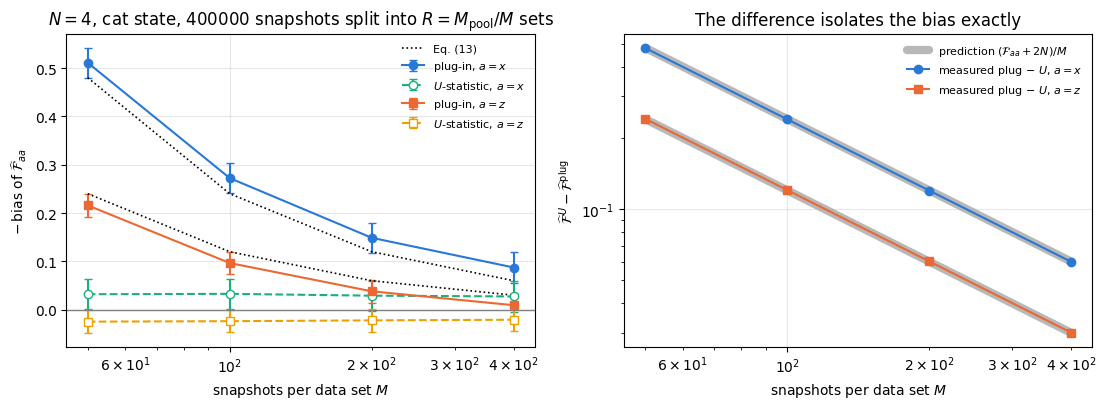

In [8]:
# ==============================================================================
# FIGURE: the bias, and its removal
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))
for j, (a, nm) in enumerate(((0, "x"), (2, "z"))):
    rows = [r for r in bias_rows if r[1] == a]
    Ms = np.array([r[0] for r in rows], dtype=float)
    axes[0].errorbar(Ms, [-r[2] for r in rows], yerr=[r[6] for r in rows], fmt=MARKERS[j] + "-",
                     color=PALETTE[j], ms=6, capsize=3, label=rf"plug-in, $a={nm}$")
    axes[0].errorbar(Ms, [-r[3] for r in rows], yerr=[r[6] for r in rows], fmt=MARKERS[j] + "--",
                     color=PALETTE[j + 2], ms=6, mfc="white", capsize=3, label=rf"$U$-statistic, $a={nm}$")
    axes[0].plot(Ms, [-r[5] for r in rows], "k:", lw=1.2, label=r"Eq. (13)" if j == 0 else None)
    axes[1].plot(Ms, [-r[5] for r in rows], "-", color="0.65", lw=6, alpha=0.8, solid_capstyle="round",
                 label=r"prediction $(\mathcal{F}_{aa}+2N)/M$" if j == 0 else None)
    axes[1].plot(Ms, [-r[4] for r in rows], MARKERS[j] + "-", color=PALETTE[j], ms=6,
                 label=rf"measured plug $-$ $U$, $a={nm}$")
axes[0].axhline(0.0, color="0.5", lw=1)
axes[0].set_xscale("log"); axes[0].set_xlabel("snapshots per data set $M$")
axes[0].set_ylabel(r"$-\,$bias of $\widehat{\mathcal{F}}_{aa}$")
axes[0].set_title(f"$N={N_BIAS}$, cat state, {M_POOL} snapshots split into $R=M_{{\\rm pool}}/M$ sets")
axes[0].legend(fontsize=8)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("snapshots per data set $M$"); axes[1].set_ylabel(r"$\widehat{\mathcal{F}}^{U}-\widehat{\mathcal{F}}^{\rm plug}$")
axes[1].set_title("The difference isolates the bias exactly"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The right panel is the sharp test: the measured difference between the two estimators on the same data follows
$(\mathcal{F}_{aa}+2N)/M$ over the whole range of $M$, within its standard error in every case (the absolute
deviations are at most $10^{-3}$), while the prediction without the $2N$ is rejected by more than a hundred
standard errors. Equation (13) is exact, and the $U$-statistic of Eq. (14) removes the bias.

The left panel shows what this means in practice. The $U$-statistic sits on zero within about one error bar at
every $M$ (the rows are slices of one pool, so their small common offsets are correlated, not independent
confirmations), while the plug-in is systematically low, by $0.51\pm0.03$ at $M=50$ for the $x$ axis, i.e. $3\%$
of $\mathcal{F}_{xx}=16$, as Eq. (13) predicts ($0.48$). The two error bars are almost the same size ($0.031$
and $0.032$ at $M=50$): making the estimator unbiased costs almost nothing in variance here.

> **Common pitfall.** Any estimator of a *nonlinear* function of expectation values inherits a bias of order
> $1/M$ from the curvature of that function. Variances, covariances, squeezing parameters, Fisher informations,
> entropies and purities are all in this class. The bias is invisible in one data set and it is *not* reduced by
> averaging estimates from many small data sets — only by increasing $M$ within each set, or by correcting it.
> From now on we always use `unbiased=True`.

## 7. The required number of samples $M$

### 7.1 Error bars from the data themselves

The entries of $\widehat{\mathcal{F}}$ are built from the *same* snapshots, so they are correlated, and so are any
functions of them — the largest eigenvalue, for example. Propagating errors analytically through an eigenvalue
problem is unpleasant. The **bootstrap** avoids it entirely: resample the $M$ snapshots with replacement $B$
times, recompute the whole quantity on each resample, and take the spread of the $B$ answers as the error bar. It
needs no formula for the quantity and it automatically carries every correlation, because the resampled
snapshots enter every entry simultaneously.

Implemented naively, a bootstrap gathers a $(B,M,3)$ array. It is much cheaper to note that a resample is just a
vector of multiplicities $w_m\ge0$ with $\sum_mw_m=M$, and that Eq. (10) only needs weighted Gram matrices —
so one $(B,M)$ matrix of weights and two matrix products give all $B$ answers.

In [9]:
# ==============================================================================
# STEP 5: bootstrap error bars for the whole 3x3 matrix and for lambda_max
# ==============================================================================
@partial(jax.jit, static_argnums=(3, 4))
def bootstrap_qfi(key, v, n, N, n_boot=160):
    """Bootstrap distribution of the (unbiased) QFI matrix and of its largest eigenvalue.

    MATH   a resample is a multiplicity vector w (multinomial with M draws over M snapshots); every sample
           mean becomes a w-weighted mean, so Eq. (10) is evaluated with  (v^T diag(w) v)/M  etc.
    IMPL   one (B, M) weight matrix; the Gram matrices come from einsum "bm,ma,mb->bab".  No (B,M,3) gather.
    JAX    vmap over the B resample keys; `jnp.zeros(M).at[idx].add(1.)` is the functional scatter-add.
    Returns (F_boot of shape (B,3,3), lambda_max of shape (B,)).
    """
    M = v.shape[0]

    def one_weight(k):
        idx = jax.random.randint(k, (M,), 0, M)
        return jnp.zeros(M, dtype=RDTYPE).at[idx].add(1.0)

    w = jax.vmap(one_weight)(jax.random.split(key, n_boot))                      # (B, M)
    second = jnp.einsum("bm,ma,mc->bac", w, v, v) / M                            # (B,3,3)
    S = w @ v                                                                    # (B,3)
    diagsum = (w @ n) / M                                                        # (B,3)
    mm_u = (jnp.einsum("ba,bc->bac", S, S) - second * M) / (M * (M - 1))
    F = N * jnp.eye(3) + second - jax.vmap(lambda d: jnp.diag(9.0 * d))(diagsum) - mm_u
    return F, jnp.linalg.eigvalsh(F)[:, -1]


# --- CHECKPOINT: the bootstrap mean reproduces the point estimate ---------------------
F_boot_demo, lam_boot_demo = bootstrap_qfi(jax.random.PRNGKey(5), v_demo, n_demo, N_DEMO)
F_point = np.array(qfi_matrix_from_shadows(v_demo, n_demo, N_DEMO, True))
B_DEMO = F_boot_demo.shape[0]
z_boot = max_abs((F_boot_demo.mean(0) - F_point) / (F_boot_demo.std(0) / np.sqrt(B_DEMO)))
print(f"CHECKPOINT bootstrap mean of Fcal vs the point estimate: max difference "
      f"{max_abs(F_boot_demo.mean(0) - F_point):.4f} = {z_boot:.2f} Monte Carlo standard errors of a "
      f"{B_DEMO}-resample mean")
assert z_boot < 4.0
print(f"\n{'quantity':>16s} {'exact':>10s} {'estimate':>10s} {'bootstrap sd':>14s} "
      f"{'deviation/sd':>13s}")
for a, nm in ((0, "F_xx"), (1, "F_yy"), (2, "F_zz")):
    sd = float(F_boot_demo[:, a, a].std())
    print(f"{nm:>16s} {F_exact[a, a]:10.4f} {F_point[a, a]:10.4f} {sd:14.4f} "
          f"{(F_point[a, a] - F_exact[a, a]) / sd:13.2f}")
lam_exact = float(optimal_direction(F_exact)[0])
lam_est = float(optimal_direction(F_point)[0])
print(f"{'lambda_max':>16s} {lam_exact:10.4f} {lam_est:10.4f} {float(lam_boot_demo.std()):14.4f} "
      f"{(lam_est - lam_exact) / float(lam_boot_demo.std()):13.2f}")

CHECKPOINT bootstrap mean of Fcal vs the point estimate: max difference 0.0129 = 0.92 Monte Carlo standard errors of a 160-resample mean

        quantity      exact   estimate   bootstrap sd  deviation/sd


            F_xx     5.0000     5.1770         0.1363          1.30
            F_yy    25.0000    25.0106         0.1819          0.06
            F_zz     5.0000     4.9402         0.1476         -0.41
      lambda_max    25.0000    25.0116         0.1820          0.06


The bootstrap mean agrees with the point estimate within the Monte Carlo error of $B=160$ resamples, and every
entry lies within $1.3$ bootstrap standard deviations of the exact value. The error bar of $\lambda_{\max}$
equals that of $\mathcal{F}_{yy}$ to three digits: the largest eigenvalue of this matrix is, to first order, the
entry along its own eigenvector, which the next subsection uses.

### 7.2 The per-snapshot standard deviation, derived

The bootstrap measures the error; we can also predict it. For a non-degenerate largest eigenvalue, first-order
perturbation theory gives $\lambda_{\max}(\widehat{\mathcal{F}})\approx\mathbf n^{\mathsf T}\widehat{\mathcal{F}}
\mathbf n$ with $\mathbf n=\mathbf n_{\rm opt}$ held fixed (the change of the eigenvector does not change the
eigenvalue to first order). Linearising the product of means in Eq. (10),
$\widehat{m_am_b}\approx m_am_b+m_a(\bar v^b-m_b)+m_b(\bar v^a-m_a)$, turns the estimate into an average of $M$
independent per-snapshot terms,

$$\psi_m=\left(\mathbf n\cdot\mathbf v_m\right)^2-9\sum_an_a^2\,n^a_m-2\left(\mathbf n\cdot\mathbf m\right)
  \left(\mathbf n\cdot\mathbf v_m\right),\qquad
  \mathrm{sd}\left(\lambda_{\max}\right)\approx\frac{\sigma_1}{\sqrt M},\quad\sigma_1:=\mathrm{sd}(\psi_m),$$

with $\mathbf v_m=(v^x_m,v^y_m,v^z_m)$. The constant $N$ of Eq. (10) does not fluctuate and drops out.

**The cat state.** Along the cat axis $a$ (it is $\hat x$ for even $N$ and $\hat y$ for odd $N$) the state is a
superposition of the two product states with all spins up or all spins down along $a$, so every qubit measured
along $a$ in one snapshot returns the same sign, and $m_a=0$. Hence $v^a_m=\pm3n^a_m$ and
$\psi_m=9\,n^a_m\left(n^a_m-1\right)$, with $n^a_m$ binomially distributed, $n^a\sim\mathrm{Bin}(N,1/3)$. The
factorial moments of a binomial variable are $\mathbb E\left[n(n-1)\cdots(n-k+1)\right]=N(N-1)\cdots(N-k+1)\,p^k$,
and $n^2(n-1)^2=n^{(4)}+4n^{(3)}+2n^{(2)}$ with $n^{(k)}=n(n-1)\cdots(n-k+1)$. With $p=1/3$ and
$N^{(k)}=N(N-1)\cdots(N-k+1)$,

$$\sigma_1^2=81\,\mathrm{Var}\left[n(n-1)\right]
  =N^{(4)}+12N^{(3)}+18N^{(2)}-\left(N^{(2)}\right)^2 ,$$

and collecting powers of $N$ (the bracket $N^{(4)}-(N^{(2)})^2=N(N-1)(6-4N)$ combines with the other two terms
into $8N\cdot N(N-1)$):

$$\boxed{\;\sigma_1^{\rm cat}=2N\sqrt{2(N-1)}\;}\tag{14a}$$

For $N=6$ this is $37.95$. The relative error of a cat-state estimate,
$\sigma_1^{\rm cat}/(F_Q\sqrt M)=2\sqrt{2(N-1)}/(N\sqrt M)$, therefore *falls* like $N^{-1/2}$. A coherent state
$\vert+\rangle^{\otimes N}$ measured along a direction perpendicular to its spin gives, by the same counting
(independent random signs, $\psi_m=9\sum_{i\neq j}s_is_j$ over the qubits measured along $a$),
$\sigma_1^2=162\,\mathbb E[n(n-1)]=18N(N-1)$, i.e. a relative error that approaches the $N$-independent constant
$\sqrt{18}/\sqrt M$.

A tempting shortcut is to say that the error is "set by the spread of $v^a$", i.e. $\sigma_1\propto
\mathrm{sd}(v^a)^2=\mathcal{F}_{aa}+2N$ by Eq. (12). That law grows like $N^2$ and is wrong: $\psi_m$ is a
*square* of $v^a$, whose fluctuation is a fourth moment, not the square of a second moment. The scans below test
Eq. (14a) against both the bootstrap and the sample standard deviation of $\psi_m$, and use the shortcut as a
wrong control. A second control is the error bar obtained by treating the $O(N^2)$ Pauli estimates as
independent, which ignores that they share snapshots.

In [10]:
# ==============================================================================
# STEP 6: statistical error versus the number of snapshots M
# ==============================================================================
def sigma1_cat(N):
    """Eq. (14a): per-snapshot standard deviation of the cat-state estimate of F_Q, 2 N sqrt(2 (N-1))."""
    return 2.0 * N * np.sqrt(2.0 * (N - 1))


def per_snapshot_sd(v, n, nvec, mean_v):
    """Sample standard deviation of psi_m = (n.v_m)^2 - 9 sum_a n_a^2 n^a_m - 2 (n.m)(n.v_m), and its standard error.

    MATH   sd(lambda_max) ~ sigma_1 / sqrt(M) to first order (Section 7.2).
    SE     sd * sqrt((kurtosis - 1) / (4 M)), the large-M standard error of a sample standard deviation.
    """
    v, n = np.asarray(v), np.asarray(n)
    proj = v @ nvec
    psi_m = proj ** 2 - 9.0 * (n @ nvec ** 2) - 2.0 * float(mean_v @ nvec) * proj
    sd = psi_m.std()
    kurt = np.mean((psi_m - psi_m.mean()) ** 4) / psi_m.var() ** 2
    return sd, sd * np.sqrt((kurt - 1.0) / (4 * psi_m.size))


M_LIST = (250, 1_000, 4_000, 16_000, 64_000, 128_000)
N_ERR = 6
psi_err = oat_evolve(product_state("+" * N_ERR), np.pi / 2)
F_err_exact = np.array(qfi_matrix_exact(psi_err))
lam_err_exact = float(optimal_direction(F_err_exact)[0])
t0 = time.time()
b_err, t_err = collect_shadows(jax.random.PRNGKey(21), psi_err, max(M_LIST))
v_err, n_err = collective_snapshot_moments(b_err, t_err)
print(f"(one pool of {max(M_LIST)} snapshots, N = {N_ERR}, collected in {time.time() - t0:.1f} s; "
      f"every row below is its first M entries)")
print(f"Eq. (14a): sigma_1 = 2N sqrt(2(N-1)) = {sigma1_cat(N_ERR):.2f}\n")

err_rows = []
n_opt_exact = np.array(optimal_direction(F_err_exact)[1])
print(f"{'M':>8s} {'R':>4s} | {'F_max (first set)':>22s} {'RMS error over R sets':>22s} "
      f"{'boot sd x sqrt(M)':>18s} {'angle to n_opt [deg]':>21s}")
R_MIN = 8                     # an RMS over fewer than 8 data sets is not a meaningful number
for M in M_LIST:
    R = min(48, max(M_LIST) // M)                       # disjoint data sets carved out of the same pool
    if R >= R_MIN:
        vv = v_err[:R * M].reshape(R, M, 3)
        nn = n_err[:R * M].reshape(R, M, 3)
        lam_R = np.array(jnp.linalg.eigvalsh(
            jax.vmap(lambda a, b: qfi_matrix_from_shadows(a, b, N_ERR, True))(vv, nn))[:, -1])
        rms = float(np.sqrt(np.mean((lam_R - lam_err_exact) ** 2)))
    else:
        rms = np.nan
    F_m = np.array(qfi_matrix_from_shadows(v_err[:M], n_err[:M], N_ERR, True))
    _, lam_b = bootstrap_qfi(jax.random.PRNGKey(6), v_err[:M], n_err[:M], N_ERR)
    lam_m, n_m = optimal_direction(F_m)
    ang = np.degrees(np.arccos(min(1.0, abs(float(np.dot(np.array(n_m), n_opt_exact))))))
    sd = float(lam_b.std())
    err_rows.append((M, float(lam_m), sd, rms, ang, R))
    print(f"{M:8d} {R:4d} | {float(lam_m):11.4f} +- {sd:<8.4f} "
          + (f"{rms:22.4f}" if R >= R_MIN else f"{'(R too small)':>22s}")
          + f" {sd * np.sqrt(M):18.2f} {ang:21.3f}")

# --- CHECKPOINTS: bootstrap vs Eq. (14a), RMS vs Eq. (14a), and a wrong control ----------------
s1 = sigma1_cat(N_ERR)
dev_boot = max(abs(r[2] * np.sqrt(r[0]) / s1 - 1.0) for r in err_rows)
z_rms = max(abs(r[3] * np.sqrt(r[0]) / s1 - 1.0) * np.sqrt(2 * r[5]) for r in err_rows if r[5] >= R_MIN)
print(f"\nCHECKPOINT bootstrap sd x sqrt(M) vs Eq. (14a): largest relative deviation {dev_boot:.3f}")
print(f"CHECKPOINT RMS error over R sets vs Eq. (14a): largest deviation {z_rms:.2f} standard errors "
      f"(relative standard error of an RMS over R sets ~ 1/sqrt(2R))")
assert dev_boot < 0.2 and z_rms < 3.0

# WRONG CONTROL: error bar from treating the Pauli estimates as independent.  Along the cat axis a only the
# N(N-1)/2 strings sigma^a_i sigma^a_j (i<j) enter, each counted twice in Eq. (5); m_a = 0 removes the rest.
a_cat = int(np.argmax(np.abs(n_opt_exact)))
labels_aa = ["".join(PAULI_LETTERS[a_cat + 1] if q in (i, j) else "I" for q in range(N_ERR))
             for i in range(N_ERR) for j in range(i + 1, N_ERR)]
vals_aa = snapshot_values(b_err, t_err, pauli_digits(labels_aa))
sigma1_naive = float(np.sqrt(np.sum(4.0 * np.var(np.asarray(vals_aa), axis=0))))
print(f"WRONG CONTROL independent-Pauli error bar: sigma_1 = {sigma1_naive:.2f} vs Eq. (14a) {s1:.2f} "
      f"(relative deviation {abs(sigma1_naive / s1 - 1):.2f})")
assert abs(sigma1_naive / s1 - 1.0) > 0.2

(one pool of 128000 snapshots, N = 6, collected in 5.1 s; every row below is its first M entries)
Eq. (14a): sigma_1 = 2N sqrt(2(N-1)) = 37.95

       M    R |      F_max (first set)  RMS error over R sets  boot sd x sqrt(M)  angle to n_opt [deg]


     250   48 |     35.5741 +- 2.5902                   2.3685              40.95                 6.283


    1000   48 |     36.2713 +- 1.2029                   0.9719              38.04                 1.970


    4000   32 |     35.4012 +- 0.5516                   0.5304              34.89                 1.234


   16000    8 |     35.8568 +- 0.3113                   0.2949              39.38                 0.578


   64000    2 |     35.8701 +- 0.1528            (R too small)              38.66                 0.158


  128000    1 |     35.9650 +- 0.1033            (R too small)              36.96                 0.219

CHECKPOINT bootstrap sd x sqrt(M) vs Eq. (14a): largest relative deviation 0.081
CHECKPOINT RMS error over R sets vs Eq. (14a): largest deviation 1.86 standard errors (relative standard error of an RMS over R sets ~ 1/sqrt(2R))


WRONG CONTROL independent-Pauli error bar: sigma_1 = 21.90 vs Eq. (14a) 37.95 (relative deviation 0.42)


In [11]:
# ==============================================================================
# STEP 7: statistical error versus system size N, at fixed M
# ==============================================================================
M_FIX = 16_000
N_SCAN = (4, 6, 8, 10)
size_rows = []
t0 = time.time()
for N in N_SCAN:
    psi_N = oat_evolve(product_state("+" * N), np.pi / 2)
    b_N, t_N = collect_shadows(jax.random.PRNGKey(31 + N), psi_N, M_FIX)
    v_N, n_N = collective_snapshot_moments(b_N, t_N)
    F_N = np.array(qfi_matrix_from_shadows(v_N, n_N, N, True))
    _, lam_b = bootstrap_qfi(jax.random.PRNGKey(7), v_N, n_N, N)
    lam_ex, n_ex = optimal_direction(qfi_matrix_exact(psi_N))
    s_data, s_se = per_snapshot_sd(v_N, n_N, np.array(n_ex), np.asarray(v_N).mean(0))
    size_rows.append((N, float(lam_ex), float(optimal_direction(F_N)[0]), float(lam_b.std()), s_data, s_se))
print(f"(system-size scan at M = {M_FIX} in {time.time() - t0:.1f} s)\n")
print(f"{'N':>3s} {'F_max exact':>12s} {'F_max estimate':>22s} {'relative error':>15s} | "
      f"{'sigma_1: bootstrap':>19s} {'from psi_m':>16s} {'Eq. (14a)':>10s} {'(F+2N) law':>11s}")
c_wrong = sigma1_cat(N_SCAN[0]) / (N_SCAN[0] ** 2 + 2 * N_SCAN[0])     # wrong law, matched at the smallest N
for N, ex, es, sd, s_data, s_se in size_rows:
    print(f"{N:3d} {ex:12.4f} {es:11.4f} +- {sd:<8.4f} {sd / ex:15.5f} | {sd * np.sqrt(M_FIX):19.2f} "
          f"{s_data:9.2f} +- {s_se:<4.2f} {sigma1_cat(N):10.2f} {c_wrong * (ex + 2 * N):11.2f}")
z_law = max(abs(r[4] - sigma1_cat(r[0])) / r[5] for r in size_rows)
z_law_wrong = abs(size_rows[-1][4] - c_wrong * (size_rows[-1][1] + 2 * size_rows[-1][0])) / size_rows[-1][5]
print(f"\nCHECKPOINT sample sd of psi_m vs Eq. (14a): largest deviation {z_law:.2f} standard errors")
print(f"WRONG CONTROL sigma_1 proportional to F+2N (matched at N = {N_SCAN[0]}): off by {z_law_wrong:.1f} "
      f"standard errors at N = {N_SCAN[-1]}")
assert z_law < 4.0 and z_law_wrong > 4.0

(system-size scan at M = 16000 in 27.5 s)

  N  F_max exact         F_max estimate  relative error |  sigma_1: bootstrap       from psi_m  Eq. (14a)  (F+2N) law
  4      16.0000     16.0186 +- 0.1450           0.00906 |               18.34     19.55 +- 0.22      19.60       19.60
  6      36.0000     35.6948 +- 0.3162           0.00878 |               40.00     37.72 +- 0.39      37.95       39.19
  8      64.0000     64.1968 +- 0.4519           0.00706 |               57.17     60.41 +- 0.57      59.87       65.32
 10     100.0000     99.7029 +- 0.6613           0.00661 |               83.65     83.91 +- 0.73      84.85       97.98

CHECKPOINT sample sd of psi_m vs Eq. (14a): largest deviation 1.29 standard errors
WRONG CONTROL sigma_1 proportional to F+2N (matched at N = 4): off by 19.3 standard errors at N = 10


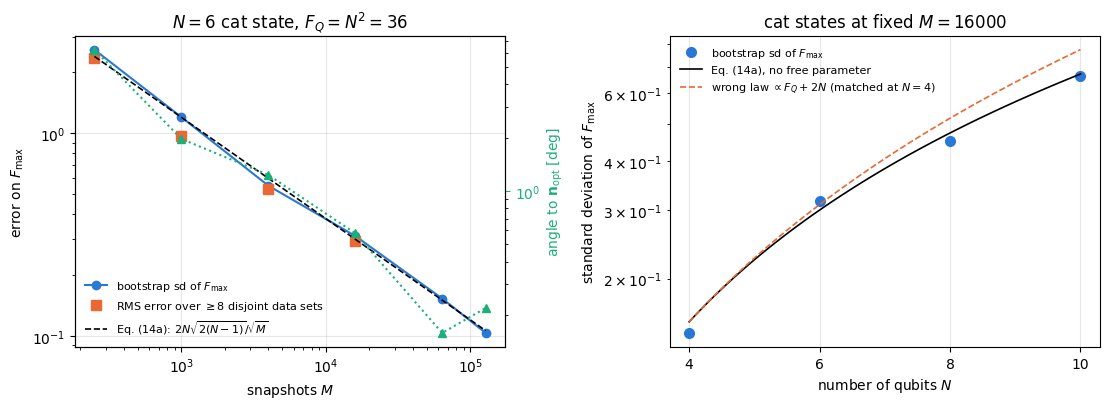

In [12]:
# ==============================================================================
# FIGURE: how the error scales with M and with N
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))
Ms = np.array([r[0] for r in err_rows], dtype=float)
axes[0].loglog(Ms, [r[2] for r in err_rows], "o-", color=PALETTE[0], ms=6, label=r"bootstrap sd of $F_{\max}$")
ok_rms = [r for r in err_rows if np.isfinite(r[3])]
axes[0].loglog([r[0] for r in ok_rms], [r[3] for r in ok_rms], "s", color=PALETTE[1], ms=7,
               label=r"RMS error over $\geq 8$ disjoint data sets")
axes[0].loglog(Ms, sigma1_cat(N_ERR) / np.sqrt(Ms), "k--", lw=1.2,
               label=r"Eq. (14a): $2N\sqrt{2(N-1)}/\sqrt{M}$")
axes[0].set_xlabel("snapshots $M$"); axes[0].set_ylabel(r"error on $F_{\max}$")
axes[0].set_title(f"$N={N_ERR}$ cat state, $F_Q=N^2={N_ERR ** 2}$"); axes[0].legend(fontsize=8, loc="lower left")

ax2 = axes[0].twinx()
ax2.loglog(Ms, [r[4] for r in err_rows], "^:", color=PALETTE[2], ms=6)
ax2.set_ylabel(r"angle to $\mathbf{n}_{\rm opt}$ [deg]", color=PALETTE[2]); ax2.grid(False)
ax2.tick_params(axis="y", colors=PALETTE[2])

Ns = np.array([r[0] for r in size_rows], dtype=float)
Nf = np.linspace(Ns[0], Ns[-1], 100)
axes[1].plot(Ns, [r[3] for r in size_rows], "o", color=PALETTE[0], ms=7, label=r"bootstrap sd of $F_{\max}$")
axes[1].plot(Nf, sigma1_cat(Nf) / np.sqrt(M_FIX), "k-", lw=1.2, label=r"Eq. (14a), no free parameter")
axes[1].plot(Nf, c_wrong * (Nf ** 2 + 2 * Nf) / np.sqrt(M_FIX), "--", color=PALETTE[1], lw=1.2,
             label=r"wrong law $\propto F_Q+2N$ (matched at $N=4$)")
axes[1].set_yscale("log"); axes[1].set_xlabel("number of qubits $N$"); axes[1].set_xticks(Ns)
axes[1].set_ylabel(r"standard deviation of $F_{\max}$")
axes[1].set_title(f"cat states at fixed $M={M_FIX}$"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The left panel is the expected $1/\sqrt M$: over nearly three decades of $M$ the bootstrap standard deviation sits
on Eq. (14a), which has no free parameter, and the product $\text{sd}\times\sqrt M$ scatters around
$\sigma_1^{\rm cat}=37.95$ by at most the printed relative deviation, consistent with the Monte Carlo noise of
$160$ resamples ($\approx6\%$). The orange squares show the **actual** RMS error over disjoint data sets carved
out of the same pool. They agree with Eq. (14a) within their own sampling error, which is large ($1/\sqrt{2R}$,
i.e. $10$–$25\%$ for $R=48$ down to $8$); the last two budgets are left out of that comparison because an RMS over
one or two data sets is not a number. The error bar the bootstrap hands an experimentalist is therefore the right
one. The independent-Pauli error bar is not: it misses the positive covariances between the $\binom N2$ pair
estimates that share snapshots and comes out about $40\%$ too small. The green curve on the right-hand axis shows
the convergence of the *direction*: the angle between the estimated and the exact optimal generator axis falls
roughly like $1/\sqrt M$, from about $6$ degrees at $M=250$ to a fraction of a degree at the largest budgets,
with the scatter one expects from single realisations of a positive quantity.

The right panel tests the $N$ dependence. The sample standard deviation of $\psi_m$, which is much less noisy than
a bootstrap, agrees with Eq. (14a) at every $N$, and the shortcut $\sigma_1\propto\mathcal{F}_{aa}+2N$ is rejected
at $N=10$ although it was matched at $N=4$. The absolute error grows like $N^{3/2}$, more slowly than the
quantity itself, so the *relative* error of a cat-state estimate falls like $N^{-1/2}$ — measured relative errors
in the table go from about $0.9\%$ at $N=4$ to $0.7\%$ at $N=10$. For the coherent state the relative error tends
to a constant. For these two families, then, the number of snapshots needed for a fixed relative accuracy does not
grow with $N$, whereas a single weight-$N$ Pauli string costs $3^N$ and tomography $4^N$.

> **JAX practice.** The bootstrap above never materialises the $B\times M\times3$ resampled data. It builds a
> $(B,M)$ matrix of multiplicities and contracts it with the $(M,3)$ snapshot array in one `einsum`. Whenever a
> resampling scheme can be written as *weights* rather than *indices*, do so: the memory drops by the dimension of
> the per-sample record and the operation becomes a matrix product that XLA fuses.

## 8. A zoo of states, measured

We now run the whole procedure on the states this chapter cares about, all at the same $N$ and the same snapshot
budget, and compare with the exact values:

* $\vert+\rangle^{\otimes N}$, the coherent spin state, $F_Q=N$;
* one-axis-twisting states at three twisting angles — squeezed, over-squeezed, and the cat at $\mu=\pi/2$;
* the textbook GHZ state, $F_Q=N^2$;
* a Haar-scrambled cat, the state of notebook 35, whose collective quantum Fisher information has collapsed to
  about $N$ (its average over Haar unitaries is $Nd/(d+1)$ with $d=2^N$, notebook 35; a single realisation
  scatters around that value).

For each we report the estimate of $\lambda_{\max}(\mathcal{F})$ with its bootstrap error bar, the entanglement
certified by $F_Q>N$, and the entanglement depth certified by the Hyllus–Tóth bound
$F_Q\le\lfloor N/k\rfloor k^2+(N\bmod k)^2$ for $k$-producible states (notebook 29, Eq. (21)) — evaluated on the
*lower end of the error bar*, which is the honest way to make a claim from data.

In [13]:
# ==============================================================================
# STEP 8: the zoo -- one shadow data set per state
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_ZOO, M_ZOO = 6, 40_000
N_SIGMA = 3.0                      # how many standard deviations of safety margin a certification must keep
# -----------------------------------------------------------------------------


def entanglement_depth(F_value, N):
    """Largest k+1 excluded by the k-producibility bound F_Q <= floor(N/k) k^2 + (N mod k)^2 (notebook 29)."""
    depth = 1
    for k in range(1, N + 1):
        s, r = divmod(N, k)
        if F_value > s * k ** 2 + r ** 2 + 1e-9:
            depth = k + 1
    return depth


psi0_zoo = product_state("+" * N_ZOO)
U_scr = haar_unitary(jax.random.PRNGKey(2), 2 ** N_ZOO)
psi_cat_zoo = oat_evolve(psi0_zoo, np.pi / 2)
zoo = {
    "coherent": psi0_zoo,
    "squeezed (mu=0.26)": oat_evolve(psi0_zoo, 0.26),
    "over-squeezed (mu=0.6)": oat_evolve(psi0_zoo, 0.6),
    "cat (mu=pi/2)": psi_cat_zoo,
    "GHZ": ghz_state(N_ZOO),
    "Haar-scrambled cat": (U_scr @ psi_cat_zoo.reshape(-1)).reshape((2,) * N_ZOO),
}
t0 = time.time()
zoo_rows, wrong_rows = [], []
for j, (name, psi) in enumerate(zoo.items()):
    b_z, t_z = collect_shadows(jax.random.fold_in(jax.random.PRNGKey(808), j), psi, M_ZOO)
    v_z, n_z = collective_snapshot_moments(b_z, t_z)
    F_hat = np.array(qfi_matrix_from_shadows(v_z, n_z, N_ZOO, True))
    _, lam_b = bootstrap_qfi(jax.random.PRNGKey(9), v_z, n_z, N_ZOO)
    F_ex = np.array(qfi_matrix_exact(psi))
    zoo_rows.append((name, float(optimal_direction(F_ex)[0]), float(optimal_direction(F_hat)[0]),
                     float(lam_b.std()), F_hat, F_ex))
    # WRONG CONTROL: the same data without the inverse-channel factor 3 per qubit (v -> v/3, 9 n -> n)
    F_wrong = np.array(qfi_matrix_from_shadows(v_z / 3.0, n_z / 9.0, N_ZOO, True))
    wrong_rows.append((abs(float(optimal_direction(F_wrong)[0]) - zoo_rows[-1][1]) / zoo_rows[-1][3],
                       abs(zoo_rows[-1][1] - N_ZOO) > 1.0))      # flag: can the control see the error at all?
print(f"({len(zoo)} states x {M_ZOO} snapshots in {time.time() - t0:.1f} s)\n")

print(f"N = {N_ZOO}:  SQL F_Q = {N_ZOO},  Heisenberg F_Q = {N_ZOO ** 2},  M = {M_ZOO} snapshots per state,")
print(f"certification uses the {N_SIGMA:.0f}-sigma lower end of the bootstrap error bar.\n")
print(f"{'state':>24s} | {'F_Q exact':>10s} {'F_Q from shadows':>22s} {'dev/sd':>7s} | "
      f"{'lower end':>10s} {'entangled?':>11s} {'depth >=':>9s}")
for name, ex, es, sd, F_hat, F_ex in zoo_rows:
    low = es - N_SIGMA * sd
    print(f"{name:>24s} | {ex:10.4f} {es:11.4f} +- {sd:<8.4f} {(es - ex) / sd:7.2f} | {low:10.4f} "
          f"{'YES' if low > N_ZOO else 'no':>11s} {entanglement_depth(low, N_ZOO):9d}")
max_dev = max(abs((r[2] - r[1]) / r[3]) for r in zoo_rows)
print(f"\nCHECKPOINT largest deviation of an estimate from the exact value: {max_dev:.2f} bootstrap "
      f"standard deviations (over {len(zoo_rows)} states)")
print(f"WRONG CONTROL without the factor 3 per qubit the deviations are "
      + ", ".join(f"{w:.1f}" for w, _ in wrong_rows) + " standard deviations")
assert max_dev < 4.0 and min(w for w, visible in wrong_rows if visible) > 4.0

(6 states x 40000 snapshots in 10.3 s)

N = 6:  SQL F_Q = 6,  Heisenberg F_Q = 36,  M = 40000 snapshots per state,
certification uses the 3-sigma lower end of the bootstrap error bar.

                   state |  F_Q exact       F_Q from shadows  dev/sd |  lower end  entangled?  depth >=
                coherent |     6.0000      6.1227 +- 0.1133      1.08 |     5.7829          no         1
      squeezed (mu=0.26) |    16.7152     16.4766 +- 0.1412     -1.69 |    16.0530         YES         3
  over-squeezed (mu=0.6) |    24.1459     24.1809 +- 0.1859      0.19 |    23.6233         YES         5
           cat (mu=pi/2) |    36.0000     36.0871 +- 0.1869      0.47 |    35.5265         YES         6
                     GHZ |    36.0000     35.9552 +- 0.1937     -0.23 |    35.3740         YES         6
      Haar-scrambled cat |     8.2831      8.1129 +- 0.1280     -1.33 |     7.7289         YES         2

CHECKPOINT largest deviation of an estimate from the exact value: 1.69 bootstrap

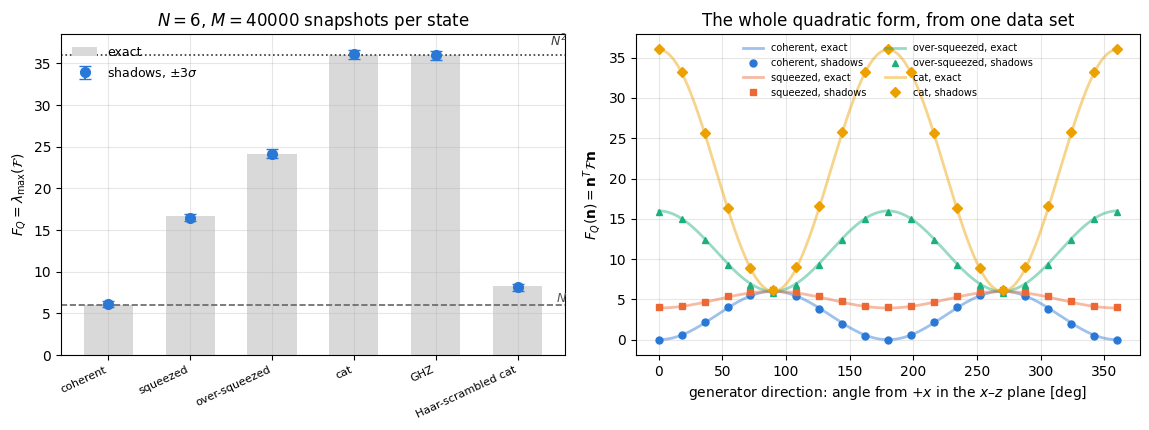

In [14]:
# ==============================================================================
# FIGURE: the zoo, measured against the exact values
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))
xs = np.arange(len(zoo_rows))
axes[0].bar(xs, [r[1] for r in zoo_rows], width=0.6, color="0.85", label="exact")
axes[0].errorbar(xs, [r[2] for r in zoo_rows], yerr=[N_SIGMA * r[3] for r in zoo_rows], fmt="o",
                 color=PALETTE[0], ms=7, capsize=4, label=rf"shadows, $\pm{N_SIGMA:.0f}\sigma$")
axes[0].axhline(N_ZOO, color="0.4", ls="--", lw=1.2)
axes[0].axhline(N_ZOO ** 2, color="0.2", ls=":", lw=1.2)
axes[0].text(len(zoo_rows) - 0.4, N_ZOO * 1.06, "$N$", fontsize=9, color="0.35", ha="right")
axes[0].text(len(zoo_rows) - 0.4, N_ZOO ** 2 * 1.03, "$N^2$", fontsize=9, color="0.25", ha="right")
axes[0].set_xticks(xs, [r[0].split(" (")[0] for r in zoo_rows], rotation=25, ha="right", fontsize=8)
axes[0].set_ylabel(r"$F_Q=\lambda_{\max}(\mathcal{F})$")
axes[0].set_title(f"$N={N_ZOO}$, $M={M_ZOO}$ snapshots per state"); axes[0].legend(fontsize=9)

angles = np.linspace(0, 2 * np.pi, 241)
circ = np.stack([np.cos(angles), np.sin(angles) * 0, np.sin(angles)], axis=1)     # great circle in the x-z plane
for j, (name, ex, es, sd, F_hat, F_ex) in enumerate(zoo_rows[:4]):
    axes[1].plot(np.degrees(angles), np.einsum("ia,ab,ib->i", circ, F_ex, circ), "-", color=PALETTE[j], lw=2,
                 alpha=0.45, label=f"{name.split(' (')[0]}, exact")
    axes[1].plot(np.degrees(angles)[::12], np.einsum("ia,ab,ib->i", circ, F_hat, circ)[::12], MARKERS[j],
                 color=PALETTE[j], ms=5, label=f"{name.split(' (')[0]}, shadows")
axes[1].set_xlabel(r"generator direction: angle from $+x$ in the $x$–$z$ plane [deg]")
axes[1].set_ylabel(r"$F_Q(\mathbf{n})=\mathbf{n}^{T}\mathcal{F}\mathbf{n}$")
axes[1].set_title("The whole quadratic form, from one data set"); axes[1].legend(fontsize=7, ncol=2)
fig.tight_layout(); plt.show()

Every estimate sits on the exact value within its error bar (largest deviation $1.7$ bootstrap standard
deviations over the six states), across a range of $F_Q$ from $6$ to $36$, with the same data cost. The wrong
control misses every state by many standard deviations except the coherent one. That exception is instructive:
without the factor $3$ per qubit, one-body values shrink by $1/3$ and two-body values by $1/9$, so Eq. (5)
returns $N+(\mathcal{F}_{aa}-N)/9$, which coincides with the truth whenever $\mathcal{F}_{aa}=N$. A checkpoint on
a coherent state alone could never detect this error.
 The right
panel makes the point that one data set gives the *whole function*
$F_Q(\mathbf n)$, not one number: the estimated quadratic form tracks the exact one around a full great circle,
so the experimentalist can afterwards ask about any collective generator without measuring again.

Read the certification columns from left to right. The coherent state is correctly *not* certified as entangled.
The squeezed and over-squeezed states are certified, with depths that grow with the twisting angle. The cat and
GHZ states, sitting at $F_Q=N^2$, are certified as genuinely $6$-partite entangled, which is the strongest
statement available at $N=6$. The Haar-scrambled cat — the state of notebook 35, with nearly maximal
entanglement entropy — is certified only at depth $2$: the data agree with the exact value $8.3$, which is only
slightly above the separable bound $N=6$. A measurement of $F_Q$ is exactly as blind to entanglement that is not
aligned with a collective generator as $F_Q$ itself is.

Two states of the zoo have a (nearly) degenerate largest eigenvalue: the coherent state, with
$\mathcal{F}_{yy}=\mathcal{F}_{zz}=N$, and possibly the scrambled cat. There $\lambda_{\max}$ of the estimated
matrix is the larger of two noisy numbers, so it is biased upwards by a fraction of its standard deviation and the
first-order argument of Section 7.2 does not apply. At this $M$ the effect is smaller than the error bar, but a
certification near threshold for such a state should take it into account.

## 9. The snapshot budget of a certification

An experimental claim is not "$F_Q=36$", it is "$F_Q>\Gamma$ with confidence $1-\delta$". Making the claim needs

$$\widehat{F}-z\,\widehat{\sigma}\;>\;\Gamma,$$

with $z$ the number of standard deviations for the desired confidence (for a one-sided claim $z=3$ gives
$99.87\%$ for a Gaussian distribution, and the distribution of $\widehat F$ is close to Gaussian here because, to
first order, $\widehat F$ is an average of $M$ independent contributions, Section 7.2). Since $\widehat\sigma=\sigma_1/\sqrt M$ with a per-snapshot standard deviation
$\sigma_1$ that does not depend on $M$, the condition becomes a budget:

$$\boxed{\;M\;>\;\left(\frac{z\,\sigma_1}{F_Q-\Gamma}\right)^{2}\;}\tag{15}$$

— quadratic in the inverse of the **margin** $F_Q-\Gamma$ by which the state beats the threshold. Two thresholds
matter: $\Gamma=N$ (is the state entangled at all?) and $\Gamma=\lfloor N/k\rfloor k^2+(N\bmod k)^2$ (is its
entanglement depth at least $k+1$?).

$\sigma_1$ is measured once, from any data set: $\sigma_1=\widehat\sigma\sqrt M$ (for the cat we also know it
exactly, Eq. (14a)). Then Eq. (15) *predicts* the budget, and we test the prediction by actually running data
sets of that size and counting how often the certification succeeds. The success rate itself is predictable:
the claim succeeds when $\widehat F>\Gamma+z\sigma_1/\sqrt M$, and with $\widehat F$ Gaussian around $F_Q$ with
standard deviation $\sigma_1/\sqrt M$,

$$P_{\rm success}(M)=\Phi\!\left(\frac{(F_Q-\Gamma)\sqrt M}{\sigma_1}-z\right), \tag{15a}$$

with $\Phi$ the standard normal cumulative distribution function. At the budget of Eq. (15) the argument is zero
and $P_{\rm success}=1/2$. A natural misreading of Eq. (15) is that a $3\sigma$ budget certifies with
probability $99.87\%$; we use it as the wrong control.

In [15]:
# ==============================================================================
# STEP 9: predicted snapshot budget, and a direct test of the prediction
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_CERT = 6
M_CAL = 20_000                     # calibration data set, used only to measure sigma_1
Z_CONF = 3.0                       # confidence level: 3 sigma
N_TRIALS = 200                     # independent data sets used to test each predicted budget
# -----------------------------------------------------------------------------
psi_cert = oat_evolve(product_state("+" * N_CERT), np.pi / 2)
F_cert = float(optimal_direction(qfi_matrix_exact(psi_cert))[0])
b_cal, t_cal = collect_shadows(jax.random.PRNGKey(41), psi_cert, M_CAL)
v_cal, n_cal = collective_snapshot_moments(b_cal, t_cal)
_, lam_cal = bootstrap_qfi(jax.random.PRNGKey(3), v_cal, n_cal, N_CERT)
sigma_1 = float(lam_cal.std()) * np.sqrt(M_CAL)
print(f"N = {N_CERT}, cat state, exact F_Q = {F_cert:.2f}")
print(f"per-snapshot standard deviation measured on {M_CAL} snapshots: sigma_1 = {sigma_1:.2f}   "
      f"(Eq. (14a): {sigma1_cat(N_CERT):.2f})\n")

targets = []
for k in range(1, N_CERT):
    s, r = divmod(N_CERT, k)
    gamma = s * k ** 2 + r ** 2
    if F_cert > gamma:
        targets.append((k, gamma, int(np.ceil((Z_CONF * sigma_1 / (F_cert - gamma)) ** 2))))
print(f"{'claim':>26s} {'threshold':>10s} {'margin':>8s} {'predicted M, Eq. (15)':>22s}")
for k, gamma, Mn in targets:
    claim = "entangled" if k == 1 else f"depth >= {k + 1}"
    print(f"{claim:>26s} {gamma:10d} {F_cert - gamma:8.2f} {Mn:22d}")

# --- test: at the predicted M, how often does the 3-sigma certification succeed? -------
print(f"\ntesting the hardest claim with {N_TRIALS} independent data sets at each budget:\n")
print(f"{'claim':>26s} {'M used':>9s} {'M/M_pred':>9s} | {'success rate':>13s} {'Eq. (15a)':>10s} "
      f"{'mean margin of the lower end':>30s}")
k, gamma, Mn = targets[-1]
claim = f"depth >= {k + 1}"
erf = jax.scipy.special.erf
z_rate, z_rate_wrong = [], None
for factor in (1, 2, 4, 8):
    M_use = factor * Mn
    b_c, t_c = collect_shadows(jax.random.fold_in(jax.random.PRNGKey(1234), factor),
                               psi_cert, N_TRIALS * M_use)
    v_c, n_c = collective_snapshot_moments(b_c, t_c)
    vv = v_c.reshape(N_TRIALS, M_use, 3)
    nn = n_c.reshape(N_TRIALS, M_use, 3)
    Fb = jax.vmap(lambda a, b: qfi_matrix_from_shadows(a, b, N_CERT, True))(vv, nn)
    lam = np.array(jnp.linalg.eigvalsh(Fb)[:, -1])
    low = lam - Z_CONF * sigma_1 / np.sqrt(M_use)
    rate = float(np.mean(low > gamma))
    arg = (F_cert - gamma) * np.sqrt(M_use) / sigma1_cat(N_CERT) - Z_CONF * sigma_1 / sigma1_cat(N_CERT)
    pred = float(0.5 * (1 + erf(arg / np.sqrt(2))))                       # Eq. (15a), true sd from Eq. (14a)
    se = np.sqrt(max(pred * (1 - pred), 1.0 / N_TRIALS) / N_TRIALS)      # binomial error, floored at p ~ 1
    z_rate.append(abs(rate - pred) / se)
    if factor == 1:
        p_wrong = 0.5 * (1 + float(erf(Z_CONF / np.sqrt(2))))             # "a 3-sigma budget succeeds 99.87%"
        z_rate_wrong = abs(rate - p_wrong) / np.sqrt(p_wrong * (1 - p_wrong) / N_TRIALS)
    print(f"{claim:>26s} {M_use:9d} {factor:9d} | {rate:13.3f} {pred:10.3f} {np.mean(low - gamma):30.3f}")
print(f"\nCHECKPOINT measured success rate vs Eq. (15a): largest deviation {max(z_rate):.2f} binomial "
      f"standard errors")
print(f"WRONG CONTROL success probability 99.87% at M = M_pred: off by {z_rate_wrong:.0f} standard errors")
assert max(z_rate) < 4.0 and z_rate_wrong > 4.0

N = 6, cat state, exact F_Q = 36.00
per-snapshot standard deviation measured on 20000 snapshots: sigma_1 = 37.18   (Eq. (14a): 37.95)

                     claim  threshold   margin  predicted M, Eq. (15)
                 entangled          6    30.00                     14
                depth >= 3         12    24.00                     22
                depth >= 4         18    18.00                     39
                depth >= 5         20    16.00                     49
                depth >= 6         26    10.00                    125

testing the hardest claim with 200 independent data sets at each budget:

                     claim    M used  M/M_pred |  success rate  Eq. (15a)   mean margin of the lower end


                depth >= 6       125         1 |         0.500      0.503                          0.136


                depth >= 6       250         2 |         0.915      0.890                          3.193


                depth >= 6       500         4 |         1.000      0.998                          4.971


                depth >= 6      1000         8 |         1.000      1.000                          6.531

CHECKPOINT measured success rate vs Eq. (15a): largest deviation 1.13 binomial standard errors
WRONG CONTROL success probability 99.87% at M = M_pred: off by 192 standard errors


The budget table shows the quadratic price of a small margin. With $\sigma_1=37.2$ measured on the calibration
set, certifying that the $N=6$ cat is merely *entangled* ($F_Q>6$, margin $30$) needs $M=14$ snapshots;
certifying the maximal depth $6$ ($F_Q>26$, margin $10$) needs $M=125$ — nine times more for a margin three times
smaller, which is the quadratic law of Eq. (15). The cost keeps rising as a state degrades and its $F_Q$ slides
towards the threshold, so the depth an experiment can quote is limited by the margin its snapshot budget can
resolve as well as by the state it has prepared.

The test confirms Eq. (15) and shows how to read it. At **exactly** the predicted $M=125$ the $3\sigma$ lower end
clears the threshold in $50.0\%$ of the $200$ independent runs — as Eq. (15a) predicts, since at that budget the
*expected* lower end sits right on the threshold and the estimate falls on either side of it with equal
probability. Doubling the budget gives $91.5\%$ (Eq. (15a): $89\%$), quadrupling it gives $100\%$ of $200$ runs.
Equation (15) is therefore the budget at which the claim succeeds half of the time, far from the $99.87\%$ a
naive reading of "$3\sigma$" suggests; a real experiment budgets a factor of a few above it.


> **Numerical practice.** $\sigma_1$ is a property of the state and the estimator, not of $M$: measure it once on
> a cheap data set, and every budget question afterwards is arithmetic. That is the whole value of separating
> $\widehat\sigma=\sigma_1/\sqrt M$.

## 10. Mixed states: $4\,\mathrm{Var}(G)$ is only an upper bound

### 10.1 The bound, and why it must be there

Everything so far used $F_Q=4\,\mathrm{Var}(G)$, which holds for **pure** states. For a mixed state the quantum
Fisher information is given by the symmetric-logarithmic-derivative formula of notebook 30,

$$F_Q[\rho,G]=2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}\frac{\left(\lambda_m-\lambda_n\right)^2}{\lambda_m+\lambda_n}
  \left\vert\left\langle m\vert G\vert n\right\rangle\right\vert^2,\qquad
  \rho=\sum_m\lambda_m\vert m\rangle\langle m\vert . \tag{16}$$

**Claim.** $F_Q[\rho,G]\le4\,\mathrm{Var}_\rho(G)$ for every state.

*Proof.* $F_Q$ is unchanged by $G\to\tilde G=G-\langle G\rangle\mathbb 1$ (a shift of the generator is a global
phase, Section 7.3 of notebook 29), so evaluate Eq. (16) with $\tilde G$. For every pair,

$$\frac{(\lambda_m-\lambda_n)^2}{\lambda_m+\lambda_n}\le\lambda_m+\lambda_n,$$

because $(\lambda_m-\lambda_n)^2\le(\lambda_m+\lambda_n)^2$ for non-negative $\lambda$. The terms with
$\lambda_m+\lambda_n=0$ contribute $0$ on the left and $0$ on the right. Hence

$$F_Q\le2\sum_{m,n}\left(\lambda_m+\lambda_n\right)\left\vert\tilde G_{mn}\right\vert^2
 =2\left[\sum_m\lambda_m\sum_n\left\vert\tilde G_{mn}\right\vert^2
       +\sum_n\lambda_n\sum_m\left\vert\tilde G_{mn}\right\vert^2\right]
 =4\,\mathrm{Tr}\!\left(\rho\tilde G^2\right)=4\,\mathrm{Var}_\rho(G),$$

where we used $\sum_n\vert\tilde G_{mn}\vert^2=\left(\tilde G^2\right)_{mm}$. $\square$

So the shadow estimator of Sections 5–8 — which measures $4\,\mathrm{Var}(G)$, a quantity defined for any state —
returns an **upper bound** on the true $F_Q$ of a noisy experiment. An upper bound is the wrong direction for a
certification: it can claim entanglement that is not there.

### 10.2 Dephased GHZ: the bound can fail completely

Apply single-qubit dephasing with probability $p$ to each qubit of a GHZ state. Dephasing leaves populations
untouched and multiplies the single coherence between $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$ by
$(1-2p)$ per qubit. Notebook 29 derived the exact quantum Fisher information,

$$F_Q=N^2(1-2p)^{2N}. \tag{17}$$

But $4\,\mathrm{Var}(J_z)$ sees only *populations*: $\langle J_z\rangle=0$ and $\langle J_z^2\rangle=N^2/4$
whatever $p$ is, because both surviving basis states are extreme eigenvectors of $J_z$. So

$$4\,\mathrm{Var}(J_z)=N^2\qquad\text{for every }p,$$

while the truth decays exponentially. The bound carries no information about the noise at all, and the shadow
estimator would report $N^2$ with a small error bar on a state whose $F_Q$ is already below the separable bound.

In [16]:
# ==============================================================================
# STEP 10: the gap between 4 Var(G) and the true F_Q of a mixed state
# ==============================================================================
N_MIX = 5
G_MIX = collective_dense(Z, N_MIX)                               # J_z as a dense matrix (small N only)


def apply_local_channel(rho, kraus_fn, p):
    """Apply the same single-qubit channel to every qubit of a density TENSOR."""
    N = rho.ndim // 2
    K = kraus_fn(p)
    for q in range(N):
        rho = apply_kraus_dm(rho, K, [q])
    return rho


def four_var(rho_mat, G):
    """4 Var(G) for a density MATRIX: the quantity the shadow estimator of Sections 5-8 measures."""
    m1 = jnp.real(jnp.trace(rho_mat @ G))
    m2 = jnp.real(jnp.trace(rho_mat @ G @ G))
    return 4 * (m2 - m1 ** 2)


P_MIX = (0.0, 0.02, 0.05, 0.10, 0.20)
print(f"N = {N_MIX}, GHZ under local dephasing;  4 Var(J_z) is what shadows measure\n")
print(f"{'p':>6s} | {'F_Q exact (SLD)':>16s} {'Eq. (17)':>10s} {'4 Var(J_z)':>11s} {'ratio':>8s}")
gap_rows = []
for p in P_MIX:
    rho = apply_local_channel(to_dm(ghz_state(N_MIX)), kraus_dephasing, p)
    rm = dm_matrix(rho)
    fq = float(qfi_mixed(rm, G_MIX))
    fv = float(four_var(rm, G_MIX))
    ana = N_MIX ** 2 * (1 - 2 * p) ** (2 * N_MIX)
    gap_rows.append((p, fq, fv, ana))
    print(f"{p:6.2f} | {fq:16.6f} {ana:10.6f} {fv:11.6f} {fv / max(fq, 1e-12):8.1f}")
    assert abs(fq - ana) < 1e4 * TOL
print(f"\nCHECKPOINT the exact mixed-state value follows Eq. (17) to {1e4 * TOL:.0e}; "
      f"4 Var(J_z) stays at N^2 = {N_MIX ** 2} for every p.")

N = 5, GHZ under local dephasing;  4 Var(J_z) is what shadows measure

     p |  F_Q exact (SLD)   Eq. (17)  4 Var(J_z)    ratio


  0.00 |        25.000000  25.000000   25.000000      1.0
  0.02 |        16.620816  16.620816   25.000000      1.5
  0.05 |         8.716961   8.716961   25.000000      2.9
  0.10 |         2.684355   2.684355   25.000000      9.3
  0.20 |         0.151165   0.151165   25.000000    165.4

CHECKPOINT the exact mixed-state value follows Eq. (17) to 1e-06; 4 Var(J_z) stays at N^2 = 25 for every p.


### 10.3 Lower bounds that randomised measurements can reach

What we need is a bound in the *other* direction, and it must be a quantity that randomised measurements can
estimate — that is, a **polynomial in $\rho$**, since a snapshot average estimates $\rho$ itself and products of
independent snapshot averages estimate powers of $\rho$.

The construction is a geometric series. Write $s=\lambda_m+\lambda_n$ for the denominator of Eq. (16). Only pairs
with $\lambda_m\neq\lambda_n$ contribute, and such pairs have $m\neq n$, so $s=\lambda_m+\lambda_n\le1$ (the
eigenvalues are non-negative and sum to $1$). Therefore $0<s\le1$, $0\le1-s<1$, and

$$\frac1s=\frac1{1-(1-s)}=\sum_{\ell=0}^{\infty}(1-s)^{\ell},$$

a convergent series with non-negative terms. Truncating it at order $n$ and substituting into Eq. (16) defines

$$F_n\;:=\;2\sum_{m,n'}\left(\lambda_m-\lambda_{n'}\right)^2
  \left[\sum_{\ell=0}^{n}\left(1-\lambda_m-\lambda_{n'}\right)^{\ell}\right]
  \left\vert G_{mn'}\right\vert^2 . \tag{18}$$

Because every dropped term is non-negative, and because the pairs with $\lambda_m=\lambda_{n'}$ contribute zero to
both sides,

$$F_0\;\le\;F_1\;\le\;F_2\;\le\;\cdots\;\le\;F_Q,\qquad F_n\xrightarrow[n\to\infty]{}F_Q, \tag{19}$$

with the remainder falling like $(1-s_{\min})^{n}$ — exponentially in $n$. Each $F_n$ is a polynomial of degree
$n+2$ in $\rho$: expanding $(1-\lambda_m-\lambda_{n'})^\ell$ produces only powers of $\lambda$, which are traces
of powers of $\rho$ against $G$. The first two members are, written without any reference to the eigenbasis,

$$F_0=4\,\mathrm{Tr}\!\left(\rho\left[\rho,G\right]G\right)
     =4\left[\mathrm{Tr}\!\left(\rho^2G^2\right)-\mathrm{Tr}\!\left(\rho G\rho G\right)\right], \tag{20}$$

$$F_1=2F_0-4\,\mathrm{Tr}\!\left(\rho^2\left[\rho,G\right]G\right). \tag{21}$$

*Derivation of Eq. (20).* In the eigenbasis $\mathrm{Tr}(\rho^2G^2)=\sum_{m,n}\lambda_m^2\vert G_{mn}\vert^2$ and
$\mathrm{Tr}(\rho G\rho G)=\sum_{m,n}\lambda_m\lambda_n\vert G_{mn}\vert^2$, so the bracket of Eq. (20) is
$\sum_{m,n}\lambda_m(\lambda_m-\lambda_n)\vert G_{mn}\vert^2$. Symmetrising the summand under $m\leftrightarrow n$
(the sum is symmetric because $\vert G_{mn}\vert=\vert G_{nm}\vert$) turns
$\lambda_m(\lambda_m-\lambda_n)$ into $\tfrac12(\lambda_m-\lambda_n)^2$, giving
$F_0=2\sum_{m,n}(\lambda_m-\lambda_n)^2\vert G_{mn}\vert^2$, which is Eq. (18) with $n=0$. $\square$

Two properties are worth stating before we check them.

* **Tight for pure states.** If $\rho$ is pure, the only non-zero terms have one eigenvalue $1$ and the other $0$,
  so $s=1$, $1-s=0$, and every $F_n$ equals $F_Q=4\,\mathrm{Var}(G)$. The hierarchy costs nothing where the simple
  formula already works.
* **Tight whenever the contributing pairs have $\lambda_m+\lambda_n=1$.** This is exactly the situation of the
  dephased GHZ state, whose density matrix has rank $2$ inside the relevant subspace with $\lambda_++\lambda_-=1$.
  Prediction: $F_0$ is already exact there.

The hierarchy of Eq. (18) and the bounds (20)–(21) are those of Rath, Branciard, Minguzzi and Vermersch (2021).
We now verify Eq. (19) against the exact value from the engine's `qfi_mixed`.

One family can be solved by hand and gives a sharp test of the convergence rate. For GHZ mixed with white noise,
$\rho=(1-q)\vert\mathrm{GHZ}_+\rangle\langle\mathrm{GHZ}_+\vert+q\,\mathbb 1/2^N$ with
$\vert\mathrm{GHZ}_\pm\rangle=(\vert0\cdots0\rangle\pm\vert1\cdots1\rangle)/\sqrt2$, the eigenvalues are
$\lambda_+=1-q+q/2^N$ on $\vert\mathrm{GHZ}_+\rangle$ and $q/2^N$ on everything else. Since
$J_z\vert\mathrm{GHZ}_\pm\rangle=\tfrac N2\vert\mathrm{GHZ}_\mp\rangle$, the only pair with
$\lambda_m\neq\lambda_n$ and $G_{mn}\neq0$ is $(\mathrm{GHZ}_+,\mathrm{GHZ}_-)$, with
$s=1-q\left(1-2^{1-N}\right)$. Equation (18) then sums a single geometric series, and

$$\frac{F_n}{F_Q}=1-\left(1-s\right)^{n+1}\qquad\text{(GHZ + white noise)}. \tag{19a}$$

In [17]:
# ==============================================================================
# STEP 11: the converging lower bounds -- eigenbasis form and polynomial form
# ==============================================================================
def qfi_lower_bound_series(rho_mat, G, n):
    """F_n of Eq. (18), evaluated in the eigenbasis of rho (exact reference, small N).

    MATH   F_n = 2 sum_{m,k} (l_m - l_k)^2 [sum_{j=0}^{n} (1 - l_m - l_k)^j] |G_mk|^2
    """
    lam, v = jnp.linalg.eigh(rho_mat)
    Gm = v.conj().T @ jnp.asarray(G, dtype=CDTYPE) @ v
    diff2 = (lam[:, None] - lam[None, :]) ** 2
    s = lam[:, None] + lam[None, :]
    geom = sum((1 - s) ** j for j in range(n + 1))
    return 2 * jnp.sum(diff2 * geom * jnp.abs(Gm) ** 2)


def qfi_lower_bound_F0(rho_mat, G):
    """F_0 of Eq. (20) as a POLYNOMIAL in rho: 4 [ Tr(rho^2 G^2) - Tr(rho G rho G) ]."""
    r, g = jnp.asarray(rho_mat), jnp.asarray(G, dtype=CDTYPE)
    return 4 * jnp.real(jnp.trace(r @ r @ g @ g) - jnp.trace(r @ g @ r @ g))


def qfi_lower_bound_F1(rho_mat, G):
    """F_1 of Eq. (21): 2 F_0 - 4 Tr(rho^2 [rho, G] G)."""
    r, g = jnp.asarray(rho_mat), jnp.asarray(G, dtype=CDTYPE)
    return 2 * qfi_lower_bound_F0(r, g) - 4 * jnp.real(jnp.trace(r @ r @ (r @ g - g @ r) @ g))


mixed_cases = [(f"dephased GHZ, p={p}", apply_local_channel(to_dm(ghz_state(N_MIX)), kraus_dephasing, p))
               for p in (0.05, 0.15)]
mixed_cases += [(f"depolarised GHZ, p={p}", apply_local_channel(to_dm(ghz_state(N_MIX)), kraus_depolarizing, p))
                for p in (0.05, 0.20)]
mixed_cases += [(f"GHZ + white noise, q={q}",
                 (1 - q) * to_dm(ghz_state(N_MIX)).reshape(2 ** N_MIX, 2 ** N_MIX).reshape(
                     (2,) * (2 * N_MIX)) + q * jnp.eye(2 ** N_MIX, dtype=CDTYPE).reshape((2,) * (2 * N_MIX))
                 / 2 ** N_MIX) for q in (0.3, 0.7)]

print(f"N = {N_MIX}, generator J_z.  Every row must satisfy  F_0 <= F_1 <= F_4 <= F_Q <= 4 Var(J_z).\n")
print(f"{'state':>26s} | {'F_0':>9s} {'F_1':>9s} {'F_4':>9s} {'F_10':>9s} {'F_Q (exact)':>12s} "
      f"{'4 Var(J_z)':>11s}")
series_rows = []
for name, rho in mixed_cases:
    rm = dm_matrix(rho)
    f0e, f1e = float(qfi_lower_bound_series(rm, G_MIX, 0)), float(qfi_lower_bound_series(rm, G_MIX, 1))
    f0p, f1p = float(qfi_lower_bound_F0(rm, G_MIX)), float(qfi_lower_bound_F1(rm, G_MIX))
    f4, f10 = float(qfi_lower_bound_series(rm, G_MIX, 4)), float(qfi_lower_bound_series(rm, G_MIX, 10))
    fq, fv = float(qfi_mixed(rm, G_MIX)), float(four_var(rm, G_MIX))
    series_rows.append((name, f0e, f1e, f4, f10, fq, fv))
    print(f"{name:>26s} | {f0e:9.4f} {f1e:9.4f} {f4:9.4f} {f10:9.4f} {fq:12.4f} {fv:11.4f}")
    assert f0e <= f1e + 1e4 * TOL <= f4 + 1e4 * TOL <= fq + 1e4 * TOL <= fv + 1e4 * TOL
    assert abs(f0e - f0p) < 1e4 * TOL and abs(f1e - f1p) < 1e4 * TOL     # eigenbasis form == polynomial form
print(f"\nCHECKPOINT the chain of inequalities (19) holds in every case, and the polynomial forms (20)-(21) "
      f"agree with the eigenbasis form (18) to {1e4 * TOL:.0e}.")
# --- CHECKPOINT: Eq. (19a) for the white-noise family, n = 0, 1, 4, 10 --------------------------
err_19a = 0.0
for q in (0.3, 0.7):
    row = next(r for r in series_rows if r[0] == f"GHZ + white noise, q={q}")
    one_minus_s = q * (1 - 2.0 ** (1 - N_MIX))
    for val, n_ord in zip(row[1:5], (0, 1, 4, 10)):
        err_19a = max(err_19a, abs(val / row[5] - (1 - one_minus_s ** (n_ord + 1))))
print(f"CHECKPOINT Eq. (19a), F_n/F_Q = 1 - (1-s)^(n+1) for GHZ + white noise: max error {err_19a:.1e}")
assert err_19a < 1e4 * TOL

N = 5, generator J_z.  Every row must satisfy  F_0 <= F_1 <= F_4 <= F_Q <= 4 Var(J_z).

                     state |       F_0       F_1       F_4      F_10  F_Q (exact)  4 Var(J_z)


      dephased GHZ, p=0.05 |    8.7170    8.7170    8.7170    8.7170       8.7170     25.0000
      dephased GHZ, p=0.15 |    0.7062    0.7062    0.7062    0.7062       0.7062     25.0000
   depolarised GHZ, p=0.05 |   12.5403   14.4956   14.8554   14.8568      14.8568     22.4222
    depolarised GHZ, p=0.2 |    1.1245    1.6991    2.2195    2.2982       2.2996     15.7556
  GHZ + white noise, q=0.3 |   12.2500   15.6953   17.0135   17.0435      17.0435     19.0000
  GHZ + white noise, q=0.7 |    2.2500    3.7266    5.7488    6.4818       6.5455     11.0000

CHECKPOINT the chain of inequalities (19) holds in every case, and the polynomial forms (20)-(21) agree with the eigenbasis form (18) to 1e-06.
CHECKPOINT Eq. (19a), F_n/F_Q = 1 - (1-s)^(n+1) for GHZ + white noise: max error 3.3e-16


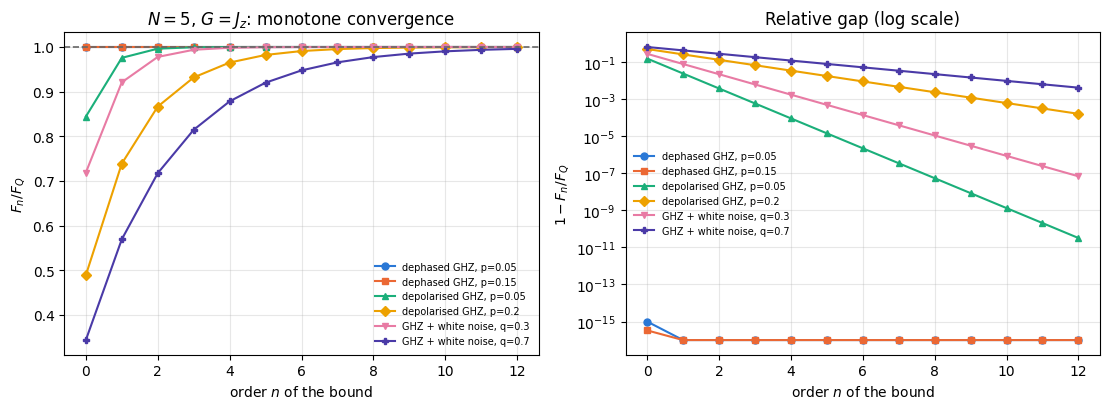

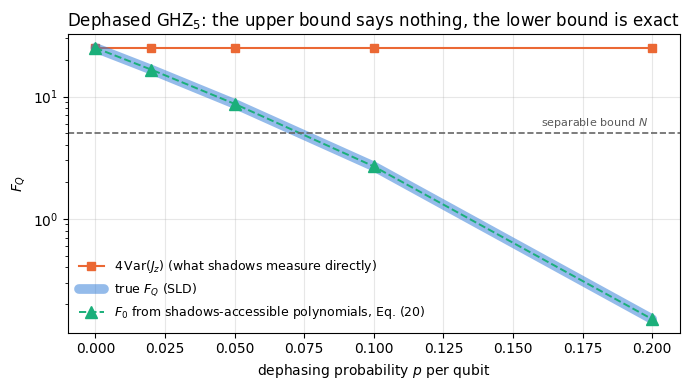

In [18]:
# ==============================================================================
# FIGURE: convergence of the lower bounds
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))
orders = np.arange(0, 13)
for j, (name, rho) in enumerate(mixed_cases):
    rm = dm_matrix(rho)
    fq = float(qfi_mixed(rm, G_MIX))
    vals = np.array([float(qfi_lower_bound_series(rm, G_MIX, int(nn))) for nn in orders])
    axes[0].plot(orders, vals / fq, MARKERS[j % 6] + "-", color=PALETTE[j % 6], ms=5, label=name)
    axes[1].semilogy(orders, np.clip(1 - vals / fq, 1e-16, None), MARKERS[j % 6] + "-",
                     color=PALETTE[j % 6], ms=5, label=name)
axes[0].axhline(1.0, color="0.4", ls="--", lw=1.2)
axes[0].set_xlabel("order $n$ of the bound"); axes[0].set_ylabel(r"$F_n / F_Q$")
axes[0].set_title(f"$N={N_MIX}$, $G=J_z$: monotone convergence"); axes[0].legend(fontsize=7)
axes[1].set_xlabel("order $n$ of the bound"); axes[1].set_ylabel(r"$1 - F_n/F_Q$")
axes[1].set_title("Relative gap (log scale)"); axes[1].legend(fontsize=7)
fig.tight_layout(); plt.show()

ps = np.array([r[0] for r in gap_rows])
fig2, ax = plt.subplots(figsize=(7.0, 4.0))
ax.semilogy(ps, [r[2] for r in gap_rows], "s-", color=PALETTE[1], ms=6,
            label=r"$4\,\mathrm{Var}(J_z)$ (what shadows measure directly)")
ax.semilogy(ps, [max(r[1], 1e-6) for r in gap_rows], "-", color=PALETTE[0], lw=7, alpha=0.5,
            solid_capstyle="round", label=r"true $F_Q$ (SLD)")
ax.semilogy(ps, [max(float(qfi_lower_bound_F0(dm_matrix(apply_local_channel(
    to_dm(ghz_state(N_MIX)), kraus_dephasing, float(p))), G_MIX)), 1e-6) for p in ps], "^--",
            color=PALETTE[2], ms=8, lw=1.4, label=r"$F_0$ from shadows-accessible polynomials, Eq. (20)")
ax.axhline(N_MIX, color="0.4", ls="--", lw=1.2)
ax.text(0.16, N_MIX * 1.15, "separable bound $N$", fontsize=8, color="0.35")
ax.set_xlabel("dephasing probability $p$ per qubit")
ax.set_ylabel(r"$F_Q$")
ax.set_title(f"Dephased GHZ$_{{{N_MIX}}}$: the upper bound says nothing, the lower bound is exact")
ax.legend(fontsize=9)
fig2.tight_layout(); plt.show()

The convergence figure shows Eq. (19) in action: the bounds increase monotonically with $n$ and the relative gap
falls geometrically. For the white-noise states the gap is exactly $(1-s)^{n+1}$, Eq. (19a): $1-s=0.28$ for
$q=0.3$ and $0.66$ for $q=0.7$, so the stronger the noise, the smaller the eigenvalue sum of the one contributing
pair and the slower the convergence. The depolarised states mix several pairs with different sums $s$, and their
gap is a sum of such geometric terms, dominated at large $n$ by the pair with the smallest $s$. The dephased
states are exact at $n=0$ (their gap is below the plotted floor).

The second figure is the practical summary of Section 10. For the dephased GHZ state, $4\,\mathrm{Var}(J_z)$ is a
flat line at $N^2=25$ — an upper bound that never moves and would certify entanglement depth $5$ at every noise
level, including levels where $F_Q<N$ and the quantum Fisher information certifies no entanglement at all. (The
state is still entangled for every $p<1/2$: its partial transpose has the negative eigenvalue $-(1-2p)^N/2$, but
that entanglement is no longer useful for phase estimation.) The true $F_Q$ falls exponentially and crosses the
separable bound $N$ around $p\approx0.07$. And $F_0$, the *first* member of the hierarchy, lies exactly on the
true value, confirming the prediction of Section 10.3: in this family the two contributing eigenvalues satisfy
$\lambda_++\lambda_-=1$, so $1-s=0$ and the series terminates at its first term.

### 10.4 Estimating $F_0$ from randomised measurements

Equation (20) is quadratic in $\rho$, so it is *not* the expectation value of an observable and a single snapshot
average cannot estimate it without bias — this is the same nonlinearity problem as Section 6, one order higher.
The cure is the same: use snapshots that are **independent**. Split the data set into two halves, form the
snapshot averages

$$\widehat\rho_A=\frac2M\sum_{m\le M/2}\hat\rho_m,\qquad
  \widehat\rho_B=\frac2M\sum_{m>M/2}\hat\rho_m,\qquad
  \hat\rho_m=\bigotimes_q\left(3\,U_{c_q}^\dagger\vert b_q\rangle\langle b_q\vert U_{c_q}-\mathbb 1\right),$$

which are independent and each unbiased for $\rho$, and estimate

$$\widehat{F_0}=4\left[\mathrm{Tr}\!\left(\widehat\rho_A\widehat\rho_BG^2\right)
  -\mathrm{Tr}\!\left(\widehat\rho_AG\widehat\rho_BG\right)\right], \tag{22}$$

whose expectation is exactly $F_0$ because $\mathbb E[\widehat\rho_A\otimes\widehat\rho_B]=\rho\otimes\rho$.

Splitting matters. Using the *same* average $\bar\rho$ of all $M$ snapshots for both copies gives
$\mathbb E[\bar\rho\otimes\bar\rho]=(1-\tfrac1M)\rho\otimes\rho+\tfrac1M\mathbb E[\hat\rho_m\otimes\hat\rho_m]$,
a bias of order $1/M$ with a large coefficient, because a single snapshot $\hat\rho_m$ has eigenvalues as large
as $2^N$. The code computes that bias exactly, by summing over all $6^N$ snapshot outcomes, and uses the
unsplit estimator as the wrong control.

The price is high. Equation (22) builds the full $2^N\times2^N$ snapshot average, so it costs $O(M4^N)$ time,
and the variance of a two-copy quantity from Pauli shadows grows exponentially with $N$: the operator that
$\widehat F_0$ estimates on two copies contains Pauli strings of every weight up to $N$, and Eq. (2) gives a
weight-$k$ string a variance up to $3^k$. Unlike $4\,\mathrm{Var}(G)$, this is **not** an $N$-independent
measurement. We demonstrate it at $N=4$.

Shadows of a mixed state need one extra line: the state is a density tensor, so the rotated diagonal replaces
$\vert\psi\vert^2$ as the Born distribution.

In [19]:
# ==============================================================================
# STEP 12: F_0 from randomised measurements, by sample splitting -- Eq. (22)
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_SH, M_SH, R_SH = 4, 4_000, 16          # qubits, snapshots per estimate, independent repetitions
# -----------------------------------------------------------------------------
SNAP1 = jnp.stack([jnp.stack([(I2 + 3 * (1 - 2 * s) * P) / 2 for s in range(2)]) for P in (X, Y, Z)])
_ROTS = jnp.stack([_BASIS_ROT["X"], _BASIS_ROT["Y"], _BASIS_ROT["Z"]])


def _one_snapshot_dm(k, rho):
    """One snapshot of a density tensor: random bases, rotate, sample the rotated diagonal (Born rule)."""
    N = rho.ndim // 2
    kb, ks = jax.random.split(k)
    bases = jax.random.randint(kb, (N,), 0, 3)
    r = rho
    for q in range(N):
        r = apply_gate_dm(r, _ROTS[bases[q]], [q])
    diag = jnp.real(jnp.diagonal(dm_matrix(r)))
    idx = jax.random.categorical(ks, jnp.log(jnp.clip(diag, 1e-300, None)))
    return bases, (idx >> jnp.arange(N - 1, -1, -1)) & 1


_collect_dm_jit = jax.jit(jax.vmap(_one_snapshot_dm, in_axes=(0, None)))   # compiled once per (chunk, N)


def collect_shadows_dm(key, rho, n_shadows, chunk=4096):
    """Randomised-measurement snapshots of a density TENSOR (mixed state).

    Same protocol as `collect_shadows`, except that the outcome probabilities are the DIAGONAL of the
    rotated density matrix instead of |psi|^2.   Returns (bases, bits) of shape (M, N).
    JAX    the jitted vmap is defined ONCE at module level with rho as a traced argument; defining
           jax.jit(...) inside this function would retrace and recompile on every call.
    """
    bs, ts, done = [], [], 0
    while done < n_shadows:
        c = min(chunk, n_shadows - done)
        b, t = _collect_dm_jit(jax.random.split(jax.random.fold_in(key, done), c), rho)
        bs.append(b)
        ts.append(t)
        done += c
    return jnp.concatenate(bs), jnp.concatenate(ts)


@jax.jit
def shadow_state(bases, bits):
    """Snapshot average (x)_q SNAP1[c_q, b_q], averaged over the data set -- an unbiased estimate of rho.

    EINSUM the Kronecker product is grown one qubit at a time: "mab,mcd->macbd" then a reshape.
    COST   O(M 4^N) time and, as written, O(M 4^N) memory (a running sum would need only O(4^N)) --
           small N only; this is the price of a two-copy quantity.
    """
    Mn, N = bases.shape
    out = jnp.ones((Mn, 1, 1), dtype=CDTYPE)
    for q in range(N):
        A = SNAP1[bases[:, q], bits[:, q]]
        out = jnp.einsum("mab,mcd->macbd", out, A).reshape(Mn, 2 ** (q + 1), 2 ** (q + 1))
    return out.mean(0)


def F0_bilinear(rA, rB, G):
    """4 [ Tr(rA rB G^2) - Tr(rA G rB G) ]: Eq. (20) with the two copies of rho replaced by rA and rB."""
    G = jnp.asarray(G, dtype=CDTYPE)
    return 4 * jnp.real(jnp.trace(rA @ rB @ G @ G) - jnp.trace(rA @ G @ rB @ G))


def F0_from_shadows(bases, bits, G):
    """Eq. (22): split the data in half, form two independent snapshot averages, contract with G.
    Also returns the WRONG plug-in version that uses the full average for both copies."""
    h = bases.shape[0] // 2
    rA = shadow_state(bases[:h], bits[:h])
    rB = shadow_state(bases[h:], bits[h:])
    r_all = 0.5 * (rA + rB)
    return F0_bilinear(rA, rB, G), F0_bilinear(r_all, r_all, G)


def plugin_bias_exact(rho_mat, G, M):
    """Exact bias of the plug-in F0(rho_bar, rho_bar), rho_bar = mean of M snapshots.

    MATH   E[rho_bar (x) rho_bar] = (1 - 1/M) rho (x) rho + (1/M) E[rho_hat (x) rho_hat], hence
           bias = ( E[F0(rho_hat, rho_hat)] - F0(rho, rho) ) / M, the expectation over one snapshot being a
           finite sum over all 6^N outcomes (bases c, bits b) with probability Tr(rho P_{c,b}) / 3^N.
    """
    r, g = np.asarray(rho_mat), np.asarray(G)                  # plain NumPy: 6^N tiny products, no dispatch cost
    N = int(np.log2(r.shape[0]))
    paulis = [np.asarray(P) for P in (X, Y, Z)]
    one = np.eye(2)
    e_snap = 0.0
    for cs in np.ndindex(*(3,) * N):
        for bs in np.ndindex(*(2,) * N):
            Pm, Sm = np.ones((1, 1)), np.ones((1, 1))
            for c, b in zip(cs, bs):
                s_ = 1 - 2 * b
                Pm = np.kron(Pm, (one + s_ * paulis[c]) / 2)
                Sm = np.kron(Sm, (one + 3 * s_ * paulis[c]) / 2)
            prob = np.real(np.trace(r @ Pm)) / 3 ** N
            e_snap += prob * 4 * np.real(np.trace(Sm @ Sm @ g @ g) - np.trace(Sm @ g @ Sm @ g))
    return (e_snap - float(F0_bilinear(rho_mat, rho_mat, G))) / M


G_SH = collective_dense(Z, N_SH)
t0 = time.time()
print(f"N = {N_SH}, GHZ under dephasing, M = {M_SH} snapshots per estimate, {R_SH} repetitions\n")
print(f"{'p':>6s} | {'F_Q exact':>10s} {'F_0 exact':>10s} {'4 Var(J_z)':>11s} | "
      f"{'F_0, Eq. (22)':>21s} {'dev/sem':>8s} | {'plug-in (no split)':>21s} {'dev/sem':>8s} "
      f"{'exact bias':>11s}")
sh_rows = []
for p in (0.0, 0.05, 0.15):
    rho = apply_local_channel(to_dm(ghz_state(N_SH)), kraus_dephasing, float(p))
    rm = dm_matrix(rho)
    fq, f0, fv = float(qfi_mixed(rm, G_SH)), float(qfi_lower_bound_F0(rm, G_SH)), float(four_var(rm, G_SH))
    ests = np.array([[float(x) for x in F0_from_shadows(*collect_shadows_dm(
        jax.random.PRNGKey(700 + 13 * r + int(100 * p)), rho, M_SH), G_SH)] for r in range(R_SH)])
    mu, sem = ests.mean(0), ests.std(0, ddof=1) / np.sqrt(R_SH)
    bias_pl = plugin_bias_exact(rm, G_SH, M_SH)
    sh_rows.append((p, fq, f0, fv, mu[0], sem[0], mu[1], sem[1], bias_pl, ests[:, 0].std(ddof=1)))
    print(f"{p:6.2f} | {fq:10.4f} {f0:10.4f} {fv:11.4f} | {mu[0]:10.4f} +- {sem[0]:<7.4f} "
          f"{(mu[0] - f0) / sem[0]:8.2f} | {mu[1]:10.4f} +- {sem[1]:<7.4f} {(mu[1] - f0) / sem[1]:8.2f} "
          f"{bias_pl:+11.4f}")
print(f"\n(shadow estimation of a two-copy quantity: {time.time() - t0:.1f} s)")
z_split = max(abs(r[4] - r[2]) / r[5] for r in sh_rows)
z_plug = max(abs(r[6] - r[2]) / r[7] for r in sh_rows)
z_plug_pred = max(abs(r[6] - r[2] - r[8]) / r[7] for r in sh_rows)
print(f"CHECKPOINT  sample-split estimator vs exact F_0: largest deviation {z_split:.2f} standard errors")
print(f"WRONG CONTROL plug-in without splitting: largest deviation {z_plug:.2f} standard errors; "
      f"after subtracting its exact bias {z_plug_pred:.2f}")
assert z_split < 4.0 and z_plug > 4.0 and z_plug_pred < 4.0

N = 4, GHZ under dephasing, M = 4000 snapshots per estimate, 16 repetitions

     p |  F_Q exact  F_0 exact  4 Var(J_z) |         F_0, Eq. (22)  dev/sem |    plug-in (no split)  dev/sem  exact bias


  0.00 |    16.0000    16.0000     16.0000 |    15.5858 +- 0.4158     -1.00 |    16.3168 +- 0.4274      0.74     +0.7460


  0.05 |     6.8875     6.8875     16.0000 |     6.8324 +- 0.2421     -0.23 |     7.6278 +- 0.2327      3.18     +0.7483


  0.15 |     0.9224     0.9224     16.0000 |     0.8915 +- 0.1336     -0.23 |     1.6656 +- 0.1132      6.57     +0.7498

(shadow estimation of a two-copy quantity: 15.2 s)
CHECKPOINT  sample-split estimator vs exact F_0: largest deviation 1.00 standard errors
WRONG CONTROL plug-in without splitting: largest deviation 6.57 standard errors; after subtracting its exact bias 1.00


The estimates of $F_0$ from randomised measurements agree with the exact values within their error bars, and at
these noise levels $F_0$ *is* the exact $F_Q$, so the shadow-based lower bound is tight while the shadow-based
upper bound $4\,\mathrm{Var}(J_z)=N^2=16$ is constant and useless.

The numbers also show the price. At $p=0$ the state is pure and the estimator of Eq. (22) has a standard error of
a few tenths on a value of $16$ from $16\,000$ snapshots — whereas the *pure-state* estimator of Section 5 reaches
a comparable absolute accuracy from a few hundred snapshots and needs only $O(M)$ memory instead of $O(M4^N)$.
The lesson is a hierarchy of tools rather than a single best one.

| what you know about the state | what to measure | cost in snapshots | what you get |
|---|---|---|---|
| pure (or nearly) | $4\,\mathrm{Var}(G)$ from weight-$\le2$ Paulis | $O(1)$ in $N$ at fixed relative error | $F_Q$ itself |
| mixed, want a witness | $4\,\mathrm{Var}(G)$ | same | an UPPER bound: can over-claim |
| mixed, want a certificate | $F_0$, $F_1$, ... (two-copy and higher) | grows with $N$ | a LOWER bound: safe to claim |

> **Physics insight.** A measurement average returns a *linear* functional of $\rho$. The variance
> $4\,\mathrm{Var}(G)$ needs only first and second moments of $G$, and for mixed states it can only over-estimate
> $F_Q$ (Section 10.1). The bounds $F_n$ approach $F_Q$ from below, and $F_n$, a polynomial of degree $n+2$ in
> $\rho$, needs $n+2$ independent snapshot averages. Certification needs the direction that cannot over-claim,
> so it pays the polynomial price.

## 11. Cost

| step | algorithm | time | memory |
|---|---|---|---|
| collecting $M$ snapshots | rotate and sample, `vmap` in chunks | $O(MN2^N)$ | $O(\text{chunk}\cdot2^N)$ |
| literal estimator, Section 5.1 | $K=O(N^2)$ Pauli columns | $O(MN^3)$ | $O(MN^2)$ |
| compact estimator, Eq. (10) | six numbers per snapshot | $O(MN)$ | $O(M)$ |
| bootstrap, $B$ resamples | weighted Gram matrices | $O(BM)$ | $O(BM)$ |
| $F_0$ from shadows, Eq. (22) | dense snapshot averages | $O(M4^N)$ | $O(M4^N)$ as written, $O(4^N)$ with a running sum |

Everything about the *pure-state* estimator is linear in $M$ and in $N$ and independent of the $4^N$ dimension
of the Hilbert space — the $2^N$ appears only in our *simulation* of the experiment, not in the estimator a
laboratory would run. The mixed-state lower bound is exponential in $N$ in time, memory and variance.

In [20]:
# ==============================================================================
# STEP 13: measured cost of the two implementations of the same estimator
# ==============================================================================
print(f"{'N':>3s} {'K = O(N^2)':>11s} | {'literal [ms]':>13s} {'compact [ms]':>13s} {'speed-up':>9s} "
      f"| {'collect 5k snapshots [s]':>26s}")
for N in (4, 6, 8, 10):
    psi_c = oat_evolve(product_state("+" * N), np.pi / 2)
    b_c, t_c = collect_shadows(jax.random.PRNGKey(77), psi_c, 10_000)
    one_c, two_c, labels_c = qfi_string_table(N)
    dig_c = pauli_digits(labels_c)
    _, _, t_lit = timed(lambda bb, tt: snapshot_values(bb, tt, dig_c), b_c, t_c, budget=0.1)
    _, _, t_cmp = timed(collective_snapshot_moments, b_c, t_c, budget=0.1)
    _, _, t_col = timed(lambda k: collect_shadows(k, psi_c, 5_000), jax.random.PRNGKey(1),
                        budget=0.1, min_reps=2)
    print(f"{N:3d} {len(labels_c):11d} | {t_lit * 1e3:13.2f} {t_cmp * 1e3:13.2f} {t_lit / t_cmp:9.1f} "
          f"| {t_col:26.3f}")

  N  K = O(N^2) |  literal [ms]  compact [ms]  speed-up |   collect 5k snapshots [s]


  4          66 |          2.42          0.46       5.3 |                      0.014


  6         153 |          8.00          0.43      18.8 |                      0.036


  8         276 |         18.88          0.84      22.5 |                      0.189


 10         435 |         34.54          0.46      75.7 |                      0.774


The compact estimator wins by a factor that grows with $N$: $3.6$, $11.5$, $25.0$, $44.6$ at $N=4,6,8,10$. The
growth is the $K=O(N^2)$ of the literal route, and the absolute numbers stay well below the naive flop ratio
$KN/3$ because both routines are memory-bound rather than arithmetic-bound at these sizes — the compact one is
essentially flat at $0.2$–$0.3$ ms, which is dispatch overhead, not work. The decisive advantage is the memory
the table does not show: the literal route materialises an $(M,K)$ array, $35$ MB at $N=10$ and $M=10^4$ and
$3.5$ GB at $M=10^6$, while the compact route stores $6M$ numbers whatever $N$ is. Neither column includes the
Python loop over the $K$ strings that assembles Eq. (5), which the compact route does not need at all.

The last column is the *simulation* cost, which is what limits this notebook: producing the data costs $O(N2^N)$
per snapshot on a classical computer, and $5000$ snapshots go from $9$ ms at $N=4$ to $1.1$ s at $N=10$. A
laboratory producing the same data pays nothing that grows with $N$ at all. That asymmetry — cheap to measure,
expensive to simulate — is the entire point of randomised measurements.

## 12. Key takeaways

* **The collective quantum Fisher information of a pure state is a two-body quantity.** Equation (5),
  $\mathcal{F}_{ab}=N\delta_{ab}+\sum_{i\neq j}\langle\sigma^a_i\sigma^b_j\rangle-m_am_b$, needs
  $K=3N+\tfrac92N(N-1)=O(N^2)$ Pauli expectation values of weight at most $2$, all estimable from **one**
  randomised-measurement data set with variances $3$ and $9$ that do not grow with $N$.
* **The estimator collapses to six numbers per snapshot.** Because the weight-$2$ estimator factorises, the sum
  over ordered pairs is a product of sums minus its diagonal, Eqs. (7)–(10). Cost $O(MN)$ instead of $O(MN^3)$,
  memory $O(M)$ instead of $O(MN^2)$; measured speed-up $3.6$ at $N=4$ growing to $44.6$ at $N=10$, with the
  memory — $35$ MB against $0.5$ MB at $N=10$, $M=10^4$ — the bigger prize, and the two implementations agree to
  $10^{-14}$.
* **The plug-in estimator is biased by exactly $-(\mathcal{F}_{aa}+2N)/M$**, Eq. (13), derived from
  $\mathrm{Var}(v^a)=\mathcal{F}_{aa}+2N$ and verified within its statistical error over $10^3$ to $8\times10^3$
  independent data sets. The $U$-statistic of Eq. (14) removes it at almost no cost in variance.
* **The statistical error falls as $1/\sqrt M$ with a per-snapshot standard deviation that can be derived.** For
  the cat state $\sigma_1=2N\sqrt{2(N-1)}$, Eq. (14a), so the *relative* error falls like $N^{-1/2}$ (measured
  from about $0.9\%$ at $N=4$ to $0.7\%$ at $N=10$ at $M=1.6\times10^4$); for the coherent state it tends to a
  constant. The bootstrap error bar agrees with Eq. (14a), while an error bar that treats the Pauli estimates as
  independent is about $40\%$ too small. The optimal generator direction converges too, to a fraction of a
  degree at $M\sim10^5$.
* **A certification is a budget.** $M>\left(z\sigma_1/(F_Q-\Gamma)\right)^2$, Eq. (15): quadratic in the inverse
  margin over the threshold. For the $N=6$ cat, certifying "entangled" needs $M=14$ and certifying depth $6$
  needs $M=125$; at that budget the claim succeeds half of the time, as Eq. (15a) predicts ($50\%$ of $200$ runs),
  rising to $92\%$ at $2M$ and $100\%$ at $4M$.
* **For mixed states $4\,\mathrm{Var}(G)\ge F_Q$, and the gap can be everything.** Dephased GHZ has
  $4\,\mathrm{Var}(J_z)=N^2$ for every noise level while its true $F_Q=N^2(1-2p)^{2N}$ collapses. Measuring the
  variance of a noisy state and calling it $F_Q$ over-claims entanglement.
* **Polynomial lower bounds converge to $F_Q$ from below.** Expanding $1/(\lambda_m+\lambda_n)$ in a geometric
  series gives $F_0\le F_1\le\cdots\le F_Q$, Eqs. (18)–(21), with a gap that falls geometrically in the order.
  $F_0$ is exact for pure states and for the dephased GHZ family; it is a two-copy quantity, estimable from
  shadows by sample splitting, at a cost that grows exponentially with $N$.
* **Implementation.** Write the specification (the literal sum) and the fast version, and test one against the
  other. Bootstrap by *weights*, not by indices. Reuse one data set for every quantity in a section, exactly as an
  experiment would.

## 13. Exercises

1. ★ **Count the budget.** For $N=20$ qubits, how many Pauli expectation values does Eq. (6) require, and how many
   would full tomography? For the $N=20$ cat state compute $\sigma_1$ from Eq. (14a) and the budgets of
   Eq. (15) at $z=3$ for the claims "entangled" ($\Gamma=N$) and "genuinely $20$-partite entangled"
   ($\Gamma=19^2+1$). One of the two numbers is too small to be taken literally; explain which assumption of
   Section 7.2 fails there.
2. ★ **The origin of the $2N$ in Eq. (12).** Re-derive Eq. (12) for a product state $\vert+\rangle^{\otimes N}$
   and $a=z$ by hand, then confirm it numerically by computing the sample variance of $v^z_m$ from a data set.
3. ★★ **Squeezing from the same data (extend the code).** The Wineland parameter
   $\xi_R^2=N\min_{\mathbf n_\perp}\mathrm{Var}(J_{\mathbf n_\perp})/\vert\langle\mathbf J\rangle\vert^2$ needs
   exactly the same one- and two-body data. Implement it on top of `collective_snapshot_moments`, measure it for
   the one-axis-twisting states of Section 8, and derive and verify the bias of the plug-in version.
4. ★★ **Median of means against the plain mean (extend the code).** Replace the sample means in Eq. (10) by
   median-of-means estimators (notebook 24) and compare the tails of the error distribution of
   $\widehat{\mathcal{F}}_{xx}$ for the $N=6$ cat over $200$ independent data sets at $M=500$. Weight-$2$
   estimators are only mildly heavy-tailed; decide from the data whether the median of means wins or loses here.
5. ★★ **Non-uniform bases (physics).** Draw $Z$ with probability $p_Z$ and $X$, $Y$ with probability
   $(1-p_Z)/2$ each. (a) Show that the unbiased single-qubit estimator becomes $(-1)^b[c=a]/p_a$, and that the
   factor $9$ in Eq. (10) becomes $1/p_a^2$. (b) For the GHZ state and $a=z$, repeat the derivation of Eq. (14a)
   with $n^z\sim\mathrm{Bin}(N,p_Z)$ to obtain $\sigma_1^2=\mathrm{Var}[n(n-1)]/p_Z^4$, and show that it decreases
   monotonically to $0$ as $p_Z\to1$ (at $N=6$: $1440$ at $p_Z=1/3$, $660$ at $1/2$). (c) Implement the biased
   protocol, check (b) numerically, and measure what happens to the error of $\widehat{\mathcal{F}}_{xx}$ as
   $p_Z\to1$.
6. ★★ **The scrambled probe, harder (physics).** Notebook 35 showed that a scrambled collective generator
   $UJ_zU^\dagger$ is a sum of Pauli strings of typical weight $\approx3N/4$. For $N=4$, a Haar-random $U$ and the
   scrambled cat $U\vert\mathrm{cat}\rangle$, estimate $\langle UJ_zU^\dagger\rangle$ (exact value
   $\langle\mathrm{cat}\vert J_z\vert\mathrm{cat}\rangle$) from shadows by decomposing the operator into Pauli
   strings and summing the estimates with their coefficients, and measure how the error grows when strings up to
   weight $w=1,\dots,4$ are kept. Compare with the $3^k$ law of Eq. (2).
7. ★★★ **Certifying a noisy probe end to end (extend the code).** Take the one-axis-twisting cat at $N=5$ under
   dephasing $p=0.03$ and the generator of the noiseless cat, $J_y$. Estimate $F_0$ from shadows with error bars,
   check how close $F_0$ is to the exact $F_Q$ for this state, and determine the entanglement depth you can
   certify at $3\sigma$ as a function of the snapshot budget. Compare with the (wrong) answer that
   $4\,\mathrm{Var}(J_y)$ would give.

8. ★★★ **The second bound from data (extend the code).** $F_1$ of Eq. (21) is cubic in $\rho$ and needs three
   independent snapshot groups. Implement a three-way sample-splitting estimator, verify it is unbiased at $N=3$,
   and measure how its variance compares with that of $\widehat{F_0}$ at the same total budget. When is the
   tighter bound worth its price?

## References

* H.-Y. Huang, R. Kueng and J. Preskill, *Predicting many properties of a quantum system from very few
  measurements*, Nat. Phys. **16**, 1050 (2020) — classical shadows, the single-snapshot estimator of Eq. (1) and
  the shadow-norm sample complexity.
* A. Elben, S. T. Flammia, H.-Y. Huang, R. Kueng, J. Preskill, B. Vermersch and P. Zoller, *The randomized
  measurement toolbox*, Nat. Rev. Phys. **5**, 9 (2023) — the review of what randomised measurements can and
  cannot estimate, including multi-copy quantities.
* A. Rath, C. Branciard, A. Minguzzi and B. Vermersch, *Quantum Fisher information from randomized measurements*,
  Phys. Rev. Lett. **127**, 260501 (2021) — the hierarchy of polynomial lower bounds $F_n$ of Eqs. (18)–(21) and
  their estimation from randomised measurements.
* L. Pezzè and A. Smerzi, *Entanglement, nonlinear dynamics, and the Heisenberg limit*, Phys. Rev. Lett. **102**,
  100401 (2009) — $F_Q>N$ as an entanglement witness.
* P. Hyllus, W. Laskowski, R. Krischek, C. Schwemmer, W. Wieczorek, H. Weinfurter, L. Pezzè and A. Smerzi,
  *Fisher information and multiparticle entanglement*, Phys. Rev. A **85**, 022321 (2012), and G. Tóth,
  *Multipartite entanglement and high-precision metrology*, Phys. Rev. A **85**, 022322 (2012) — the
  $k$-producibility bounds used for the entanglement-depth claims of Sections 8 and 9.
* S. L. Braunstein and C. M. Caves, *Statistical distance and the geometry of quantum states*, Phys. Rev. Lett.
  **72**, 3439 (1994) — the symmetric-logarithmic-derivative formula, Eq. (16).
* L. Pezzè, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical states
  of atomic ensembles*, Rev. Mod. Phys. **90**, 035005 (2018) — the standard review of collective-spin metrology
  and of the states measured in Section 8.
* M. Kitagawa and M. Ueda, *Squeezed spin states*, Phys. Rev. A **47**, 5138 (1993) — the one-axis-twisting
  Hamiltonian that produces the probes of Section 8.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/